# Предобработка временных рядов (приведение к стационарному виду для построение прогнозов с помощью VAR и далее для AR и ARIMA)

In [6]:
!pip install sktime -q
!pip install pmdarima -q

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

from scipy.signal import detrend

from sklearn.model_selection import TimeSeriesSplit

import matplotlib.pyplot as plt
from sktime.utils.plotting import plot_correlations

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.model_selection import temporal_train_test_split
from sktime.forecasting.naive import NaiveForecaster

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import GradientBoostingRegressor
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

plt.style.use('ggplot')
plt.rcParams["figure.figsize"] = (23,9)

In [8]:
def dm_test(actual_lst, pred1_lst, pred2_lst, h = 1, crit="MSE", power = 2):
    # Routine for checking errors
    def error_check():
        rt = 0
        msg = ""
        # Check if h is an integer
        if (not isinstance(h, int)):
            rt = -1
            msg = "The type of the number of steps ahead (h) is not an integer."
            return (rt,msg)
        # Check the range of h
        if (h < 1):
            rt = -1
            msg = "The number of steps ahead (h) is not large enough."
            return (rt,msg)
        len_act = len(actual_lst)
        len_p1  = len(pred1_lst)
        len_p2  = len(pred2_lst)
        # Check if lengths of actual values and predicted values are equal
        if (len_act != len_p1 or len_p1 != len_p2 or len_act != len_p2):
            rt = -1
            msg = "Lengths of actual_lst, pred1_lst and pred2_lst do not match."
            return (rt,msg)
        # Check range of h
        if (h >= len_act):
            rt = -1
            msg = "The number of steps ahead is too large."
            return (rt,msg)
        # Check if criterion supported
        if (crit != "MSE" and crit != "MAPE" and crit != "MAD" and crit != "poly"):
            rt = -1
            msg = "The criterion is not supported."
            return (rt,msg)  
        # Check if every value of the input lists are numerical values
        from re import compile as re_compile
        comp = re_compile("^\d+?\.\d+?$")  
        def compiled_regex(s):
            """ Returns True is string is a number. """
            if comp.match(s) is None:
                return s.isdigit()
            return True
        for actual, pred1, pred2 in zip(actual_lst, pred1_lst, pred2_lst):
            is_actual_ok = compiled_regex(str(abs(actual)))
            is_pred1_ok = compiled_regex(str(abs(pred1)))
            is_pred2_ok = compiled_regex(str(abs(pred2)))
            if (not (is_actual_ok and is_pred1_ok and is_pred2_ok)):  
                msg = "An element in the actual_lst, pred1_lst or pred2_lst is not numeric."
                rt = -1
                return (rt,msg)
        return (rt,msg)
    
    # Error check
    error_code = error_check()
    # Raise error if cannot pass error check
    if (error_code[0] == -1):
        raise SyntaxError(error_code[1])
        return
    # Import libraries
    from scipy.stats import t
    import collections
    import pandas as pd
    import numpy as np
    
    # Initialise lists
    e1_lst = []
    e2_lst = []
    d_lst  = []
    
    # convert every value of the lists into real values
    actual_lst = pd.Series(actual_lst).apply(lambda x: float(x)).tolist()
    pred1_lst = pd.Series(pred1_lst).apply(lambda x: float(x)).tolist()
    pred2_lst = pd.Series(pred2_lst).apply(lambda x: float(x)).tolist()
    
    # Length of lists (as real numbers)
    T = float(len(actual_lst))
    
    # construct d according to crit
    if (crit == "MSE"):
        for actual,p1,p2 in zip(actual_lst,pred1_lst,pred2_lst):
            e1_lst.append((actual - p1)**2)
            e2_lst.append((actual - p2)**2)
        for e1, e2 in zip(e1_lst, e2_lst):
            d_lst.append(e1 - e2)
    elif (crit == "MAD"):
        for actual,p1,p2 in zip(actual_lst,pred1_lst,pred2_lst):
            e1_lst.append(abs(actual - p1))
            e2_lst.append(abs(actual - p2))
        for e1, e2 in zip(e1_lst, e2_lst):
            d_lst.append(e1 - e2)
    elif (crit == "MAPE"):
        for actual,p1,p2 in zip(actual_lst,pred1_lst,pred2_lst):
            e1_lst.append(abs((actual - p1)/actual))
            e2_lst.append(abs((actual - p2)/actual))
        for e1, e2 in zip(e1_lst, e2_lst):
            d_lst.append(e1 - e2)
    elif (crit == "poly"):
        for actual,p1,p2 in zip(actual_lst,pred1_lst,pred2_lst):
            e1_lst.append(((actual - p1))**(power))
            e2_lst.append(((actual - p2))**(power))
        for e1, e2 in zip(e1_lst, e2_lst):
            d_lst.append(e1 - e2)    
    
    # Mean of d        
    mean_d = pd.Series(d_lst).mean()
    
    # Find autocovariance and construct DM test statistics
    def autocovariance(Xi, N, k, Xs):
        autoCov = 0
        T = float(N)
        for i in np.arange(0, N-k):
              autoCov += ((Xi[i+k])-Xs)*(Xi[i]-Xs)
        return (1/(T))*autoCov
    gamma = []
    for lag in range(0,h):
        gamma.append(autocovariance(d_lst,len(d_lst),lag,mean_d)) # 0, 1, 2
    V_d = (gamma[0] + 2*sum(gamma[1:]))/T
    DM_stat=V_d**(-0.5)*mean_d
    harvey_adj=((T+1-2*h+h*(h-1)/T)/T)**(0.5)
    DM_stat = harvey_adj*DM_stat
    # Find p-value
    p_value = 2*t.cdf(-abs(DM_stat), df = T - 1)
    
    # Construct named tuple for return
    dm_return = collections.namedtuple('dm_return', 'DM p_value')
    
    rt = dm_return(DM = DM_stat, p_value = p_value)
    
    return rt

In [9]:
data = pd.read_excel('Приложения_ИИ_проект (1).xlsx')

In [10]:
data

,Date,CPI,IPI,М2,exc_rate,Firms Inflation expectations,MIACR,RVI,IMOEX
0,2015-01-01,103.85,101.3,31 616,68.86,22.9,16.96,63.37,"1 647,69"
1,2015-02-01,102.22,99.8,31 034,61.62,21.7,15.12,49.60,"1 758,97"
2,2015-03-01,101.21,101.9,31 225,58.20,18.2,14.90,43.49,"1 626,18"
3,2015-04-01,100.46,99.4,31 029,51.65,14.9,14.36,35.60,"1 688,34"
4,2015-05-01,100.35,99.0,31 697,52.32,12.2,12.83,36.12,"1 609,19"
...,...,...,...,...,...,...,...,...,...
116,2024-09-01,100.48,102.9,106 243,93.00,22.1,18.46,31.02,"2 857,56"
117,2024-10-01,100.75,105.2,107 630,97.37,23.4,18.93,40.99,"2 560,2"
118,2024-11-01,101.43,103.5,108 948,106.50,25.8,20.65,55.61,2 578
119,2024-12-01,101.32,108.2,111 025,113.50,28.1,21.14,36.97,"2 883,04"


In [11]:
data.dtypes

Date                            datetime64[ns]
CPI                                    float64
IPI                                    float64
М2                                      object
exc_rate                               float64
Firms Inflation expectations           float64
MIACR                                  float64
RVI                                    float64
IMOEX                                   object
dtype: object

In [12]:
data['IMOEX'] = data['IMOEX'].apply(lambda x: x.replace(",", "."))
data['IMOEX'] = data['IMOEX'].apply(lambda x: "".join(x.split()))
data['IMOEX'] = data['IMOEX'].astype(float)
data.head()

,Date,CPI,IPI,М2,exc_rate,Firms Inflation expectations,MIACR,RVI,IMOEX
0,2015-01-01,103.85,101.3,31 616,68.86,22.9,16.96,63.37,1647.69
1,2015-02-01,102.22,99.8,31 034,61.62,21.7,15.12,49.60,1758.97
2,2015-03-01,101.21,101.9,31 225,58.20,18.2,14.90,43.49,1626.18
3,2015-04-01,100.46,99.4,31 029,51.65,14.9,14.36,35.60,1688.34
4,2015-05-01,100.35,99.0,31 697,52.32,12.2,12.83,36.12,1609.19


In [13]:
data['М2'] = data['М2'].apply(lambda x: "".join(x.split()))
data['М2'] = data['М2'].astype(int)

In [14]:
data.describe()

,CPI,IPI,М2,exc_rate,Firms Inflation expectations,MIACR,RVI,IMOEX
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,100.572066,102.656198,57606.578512,71.128430,14.942149,9.558347,32.829256,2560.137603
std,0.823119,3.574444,23055.976406,12.611393,6.437569,4.095017,15.257231,618.055123
min,99.460000,92.300000,31029.000000,51.450000,4.700000,4.060000,17.070000,1609.190000
25%,100.270000,100.400000,39276.000000,62.400000,9.700000,7.030000,22.910000,2064.310000
50%,100.430000,102.800000,50623.000000,66.880000,13.500000,7.940000,27.780000,2475.360000
75%,100.740000,105.100000,69623.000000,75.740000,19.700000,11.070000,36.230000,2948.100000
max,107.610000,112.900000,117256.000000,113.500000,41.900000,21.140000,117.330000,4150.000000


In [15]:
idx = pd.date_range('2015-01-01', periods = 121, freq='MS')
idx

DatetimeIndex(['2015-01-01', '2015-02-01', '2015-03-01', '2015-04-01',
               '2015-05-01', '2015-06-01', '2015-07-01', '2015-08-01',
               '2015-09-01', '2015-10-01',
               ...
               '2024-04-01', '2024-05-01', '2024-06-01', '2024-07-01',
               '2024-08-01', '2024-09-01', '2024-10-01', '2024-11-01',
               '2024-12-01', '2025-01-01'],
              dtype='datetime64[ns]', length=121, freq='MS')

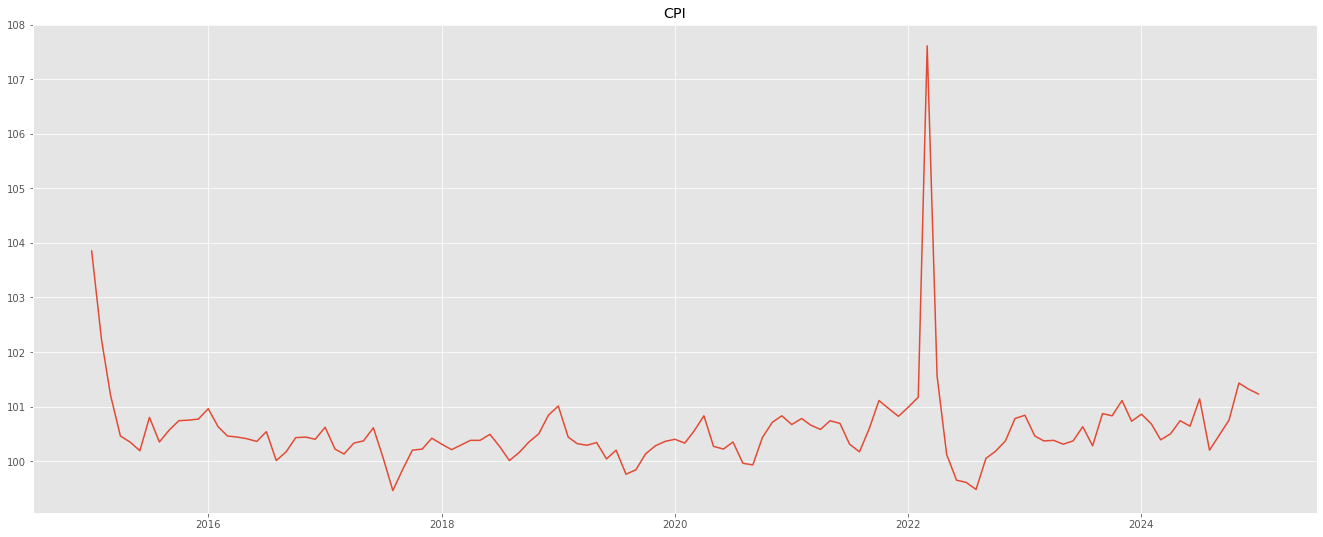

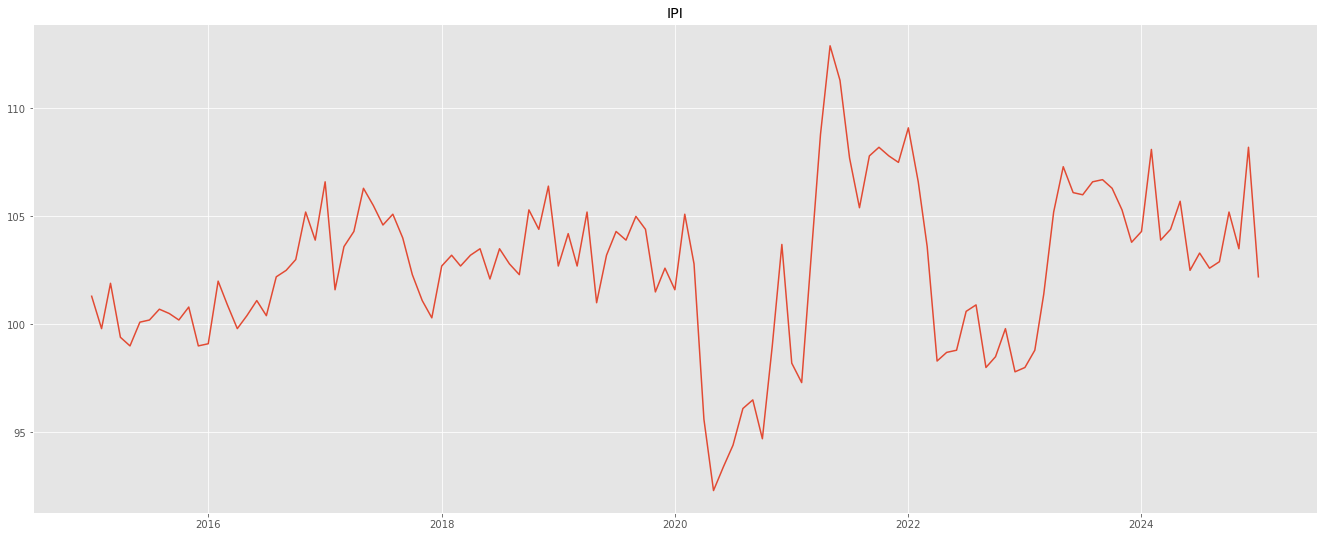

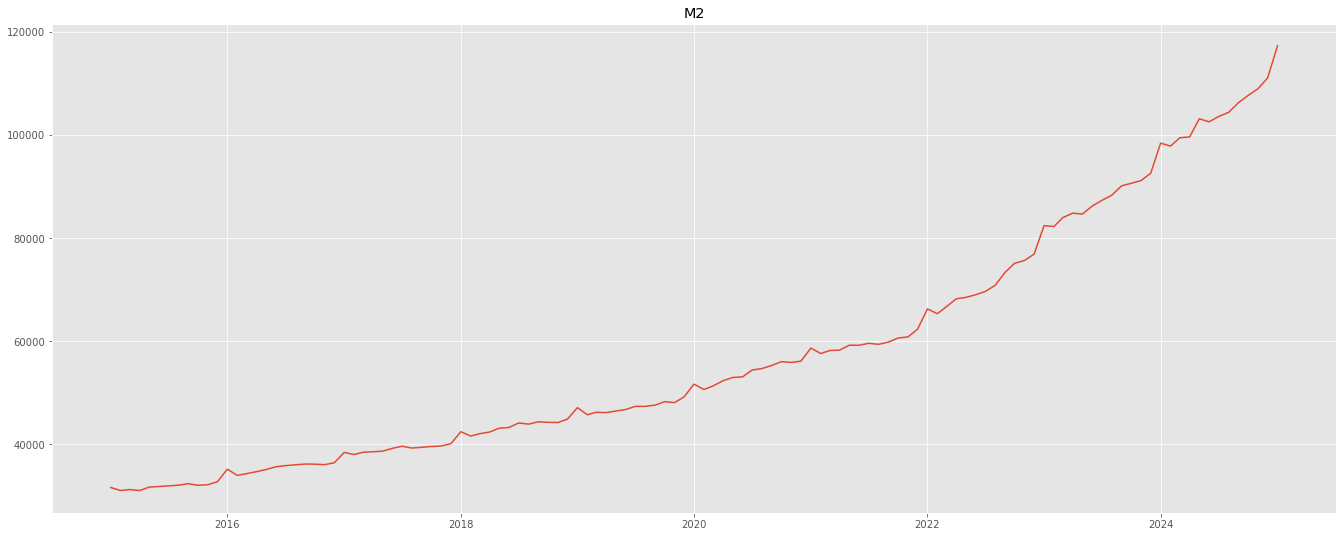

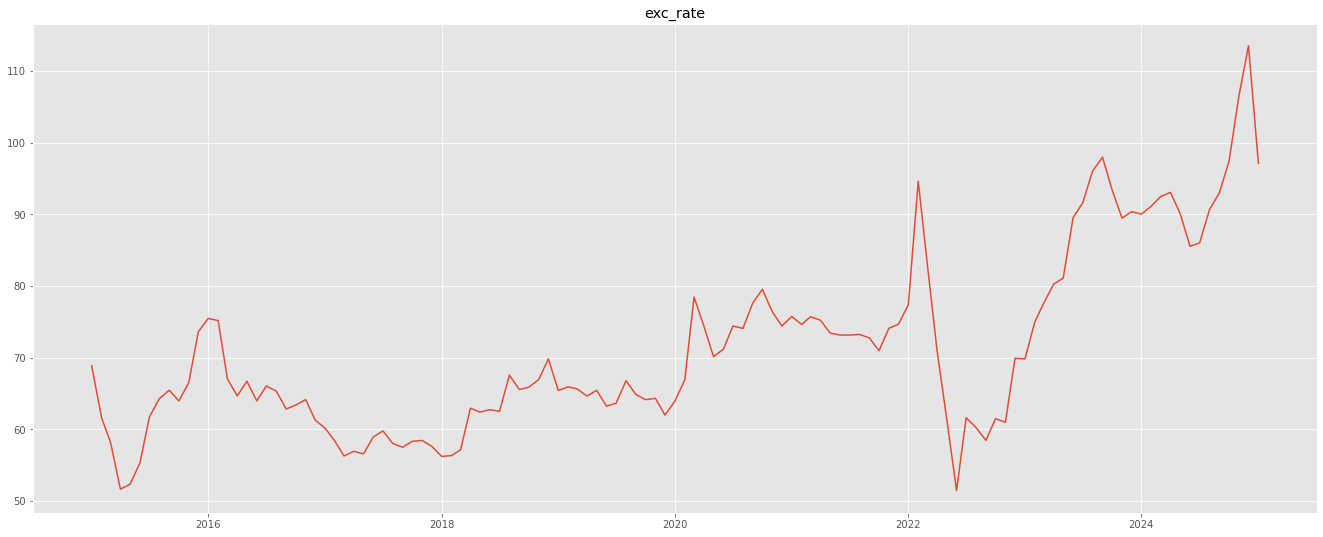

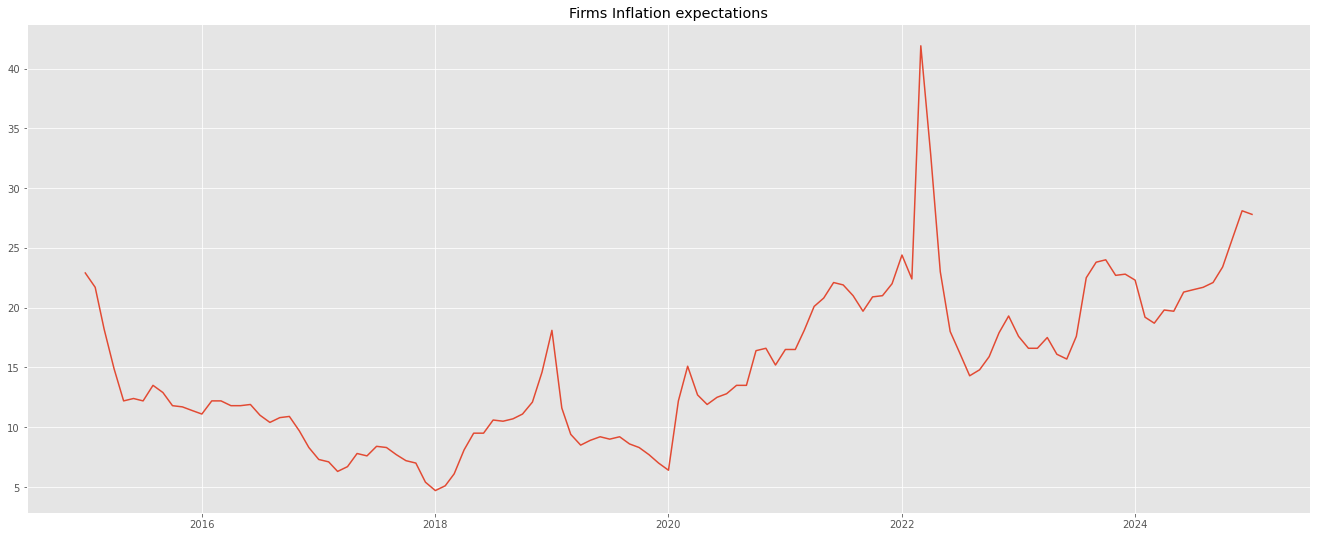

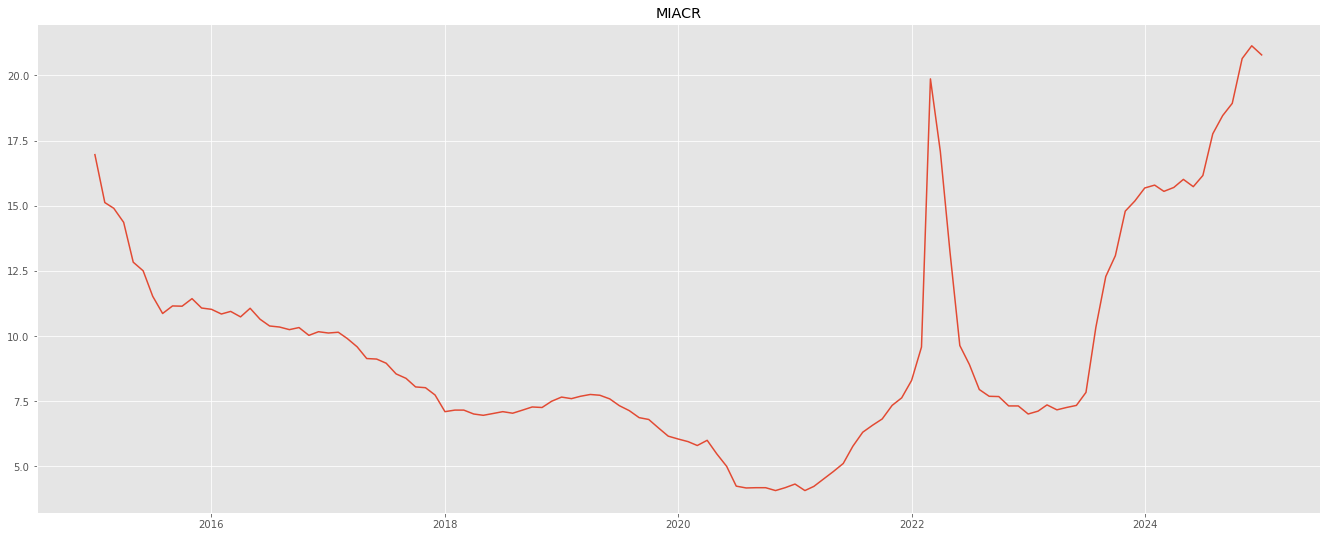

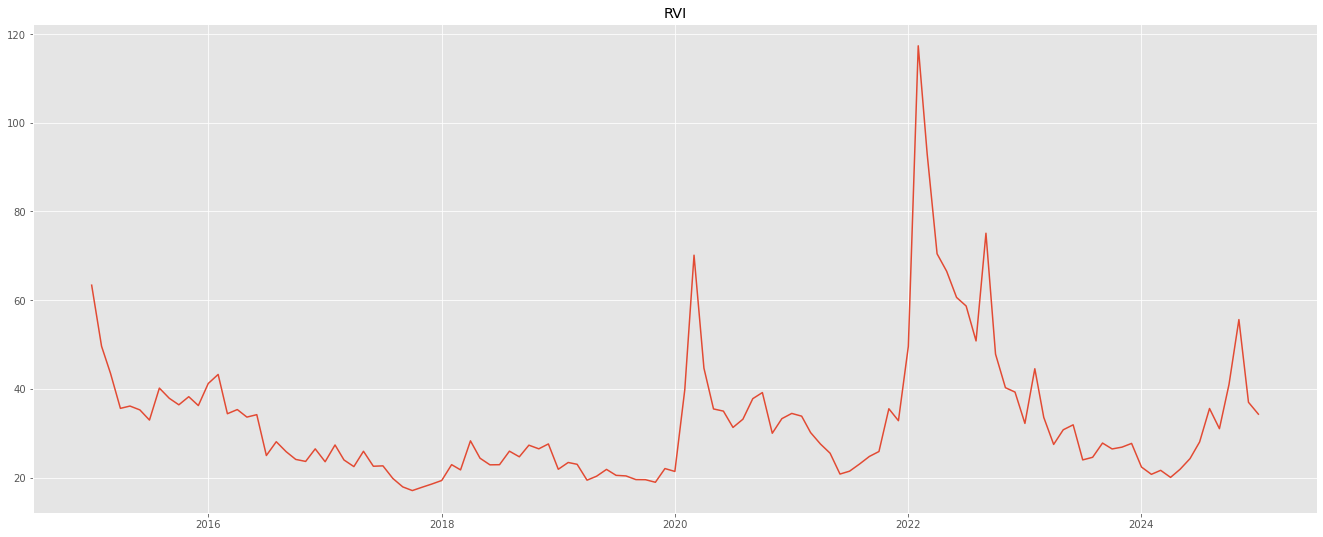

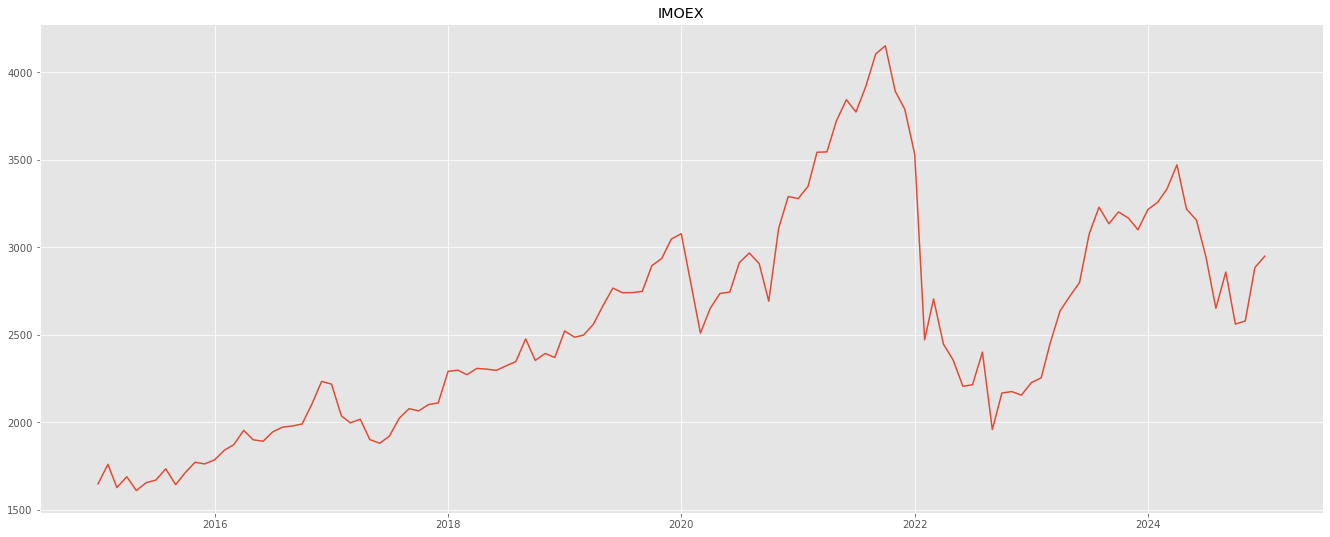

In [16]:
names = ['CPI', 'IPI', 'М2', 'exc_rate', 'Firms Inflation expectations','MIACR', 'RVI', 'IMOEX']
for i in data.columns[1:]:
    plt.figure()  
    plt.plot(idx, data[i])
    plt.title(names[list(data.columns[1:]).index(i)]) 
    plt.show() 

Приведение к стационарному виду ряда - CPI (ИПЦ)

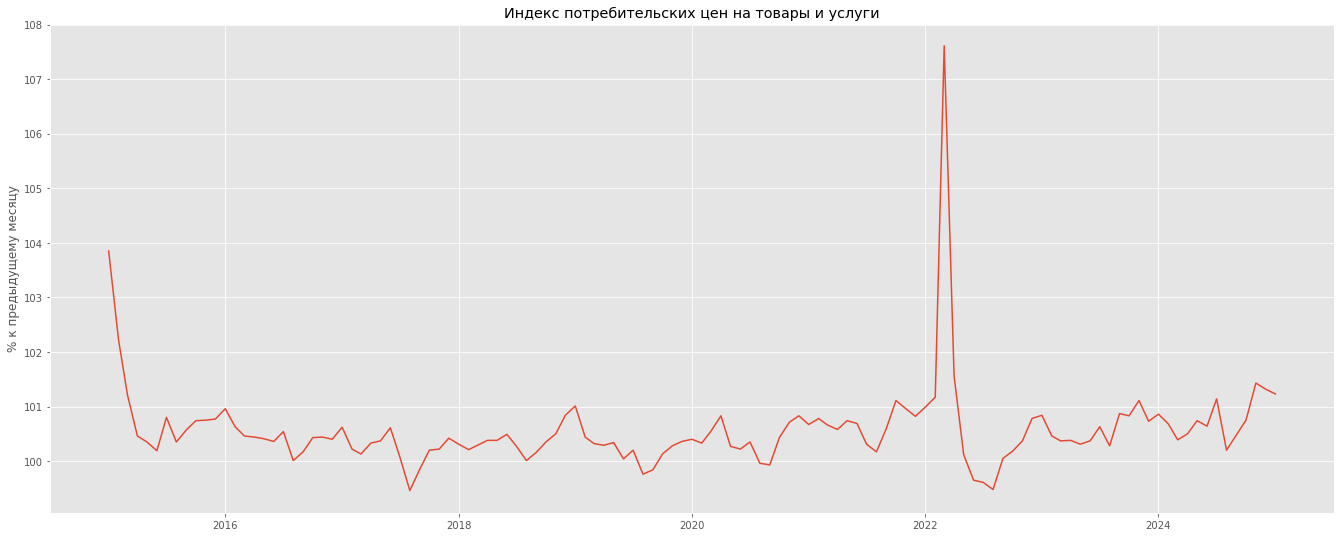

In [17]:
plt.plot(idx, data['CPI'])
plt.title('Индекс потребительских цен на товары и услуги')
plt.ylabel('% к предыдущему месяцу')
plt.savefig('ИПЦ_до.png')

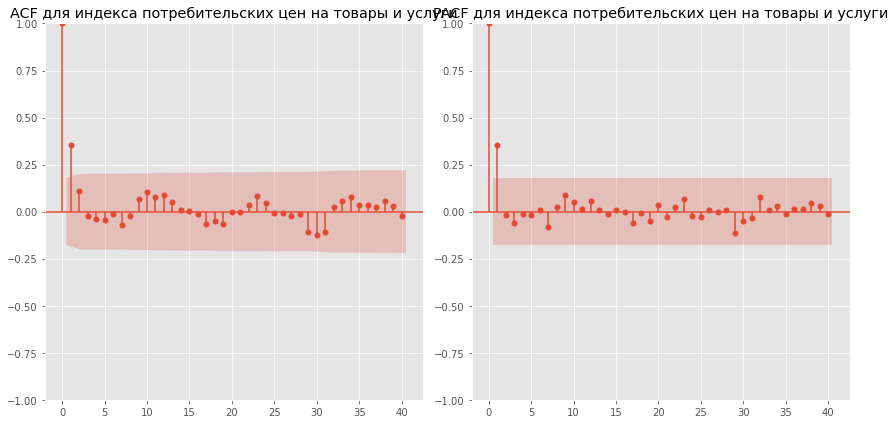

In [18]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sm.graphics.tsa.plot_acf(data['CPI'], lags=40, ax=plt.gca())
plt.title(f"ACF для индекса потребительских цен на товары и услуги")
plt.subplot(1, 2, 2)
sm.graphics.tsa.plot_pacf(data['CPI'], lags=40, ax=plt.gca(), method='ywm')  
plt.title(f"PACF для индекса потребительских цен на товары и услуги")
plt.savefig('ИПЦ_PACF.png')
plt.tight_layout()
plt.show()

В ряду ИПЦ наблюдаются характерные пики в каждом году примерно в январе и июле, что может быть объяснено частым увеличением цен на тарифы ЖКХ, проезд в транспорте и др. в данные периоды. Кроме того, есть выбросы в ряде: значение ИПЦ в марте 2022 года, а также январе 2015 года, что мы учтем путем добавления дамми-переменных на эти даты при спецификации VAR-модели. 
Графики автокорреляционной (ACF) и частной автокорреляционной (PACF) функций показывают статистически значимые коэффициенты для первого лага, после чего значения коэффициентов быстро снижаются до нуля, что может служить потенциальным индикатором стационарности ряда. При этом на графике ACF не статистически значимые коэффициенты автокорреляции для лагов больше второго демонстрируют характерный паттерн, который может свидетельствовать о наличии сезонности. Нами были предприняты попытки убрать сезонную компоненту из ряда путем логарифмирования, сезонной декомпозиции с мультипликативной и аддитивной ошибками, взятия 1, 7, 12 разностей. Однако результаты значительно не улучшились, поэтому для сохранения наибольшей информации в данных приняли решение использовать исходный ряд. Кроме того, расширенный тест Дикки-Фуллера и KPSS тест показывают, что ряд стационарен на всех адекватных уровнях значимости. Для учета возможной сезонности ИПЦ будут использованы дамми-переменные на номер месяца года в модели. 

In [19]:
# ADF Test  с констатой для CPI
result = adfuller(data['CPI'], regression = 'c',autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[1]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
#Отвергается нулевая гипотеза о наличии единичного корня на 1%, 5%, 10% уровнях значимости 

ADF Statistic: -8.093735360962889
n_lags: 1.3564762586772641e-12
p-value: 1.3564762586772641e-12
Critial Values:
   1%, -3.486055829282407
Critial Values:
   5%, -2.8859430324074076
Critial Values:
   10%, -2.5797850694444446


In [20]:
print(f'KPSS test, p-value: {sm.tsa.stattools.kpss(data["CPI"], regression = "c")[1]}')
#Нулевая гипотеза о стационарности процесса не отвергается на 1%, 5%, 10% уровнях значимости

KPSS test, p-value: 0.1


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


Приведение к стационарному виду ряда - IPI (Индекс промышленного производства)

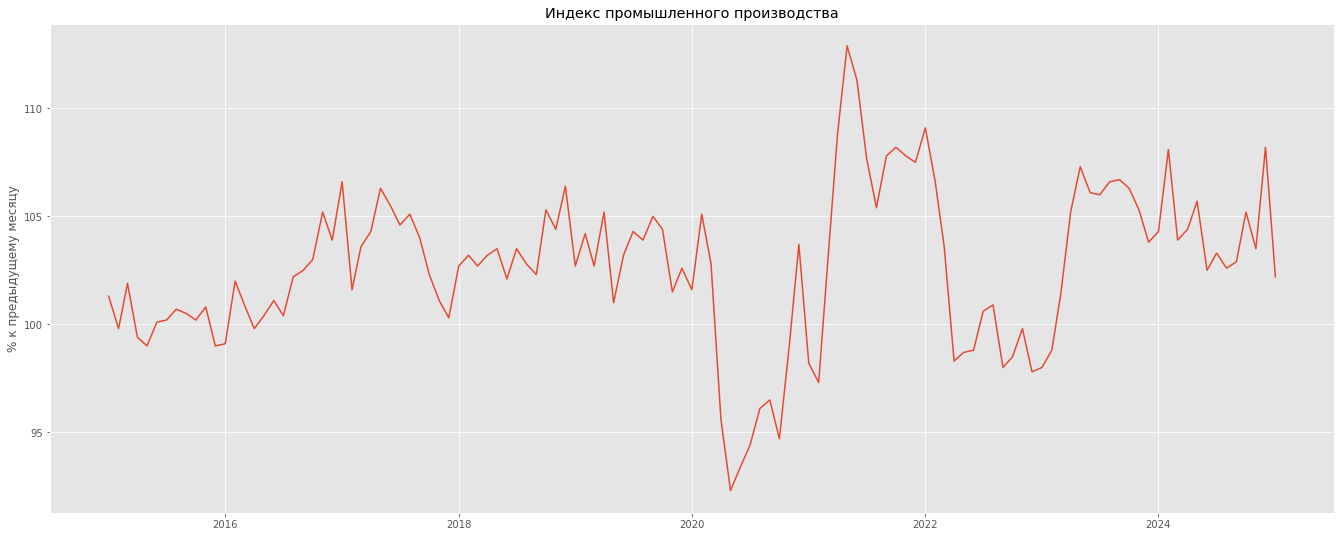

In [21]:
plt.plot(idx, data['IPI'])
plt.title('Индекс промышленного производства')
plt.ylabel('% к предыдущему месяцу')
plt.savefig('ИПП_до.png')

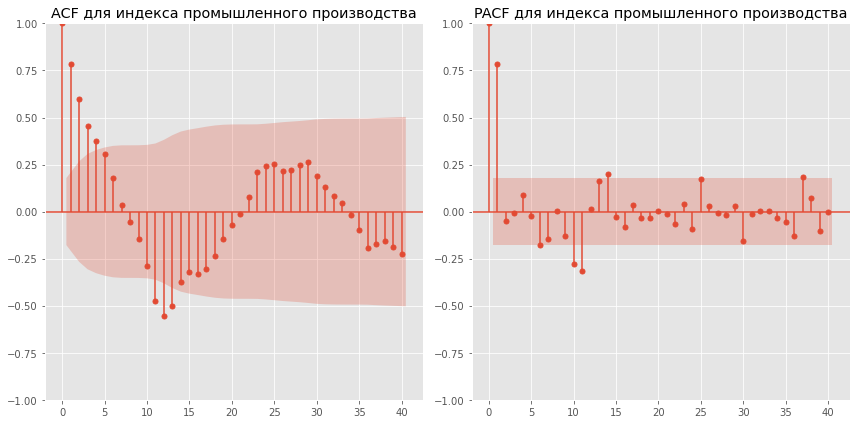

In [22]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sm.graphics.tsa.plot_acf(data['IPI'], lags=40, ax=plt.gca())
plt.title(f"ACF для индекса промышленного производства")
plt.subplot(1, 2, 2)
sm.graphics.tsa.plot_pacf(data['IPI'], lags=40, ax=plt.gca(), method='ywm')  
plt.title(f"PACF для индекса промышленного производства")
plt.tight_layout()
plt.show()

In [23]:
# ADF Test  с констатой для CPI
result = adfuller(data['IPI'], regression = 'c',autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[1]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
#Не отвергается нулевая гипотеза о наличии единичного корня на 5%, 10% уровнях значимости 

ADF Statistic: -2.7528265358920447
n_lags: 0.0653344932040481
p-value: 0.0653344932040481
Critial Values:
   1%, -3.492995948509562
Critial Values:
   5%, -2.888954648057252
Critial Values:
   10%, -2.58139291903223


In [24]:
#Логарифмическая трансформация для снижения сезонности, которая ярко выражена на графике для ACF
ipi = np.log(1 + data['IPI'])

In [25]:
#Взятие первой разности
ipi = ipi.diff(1)

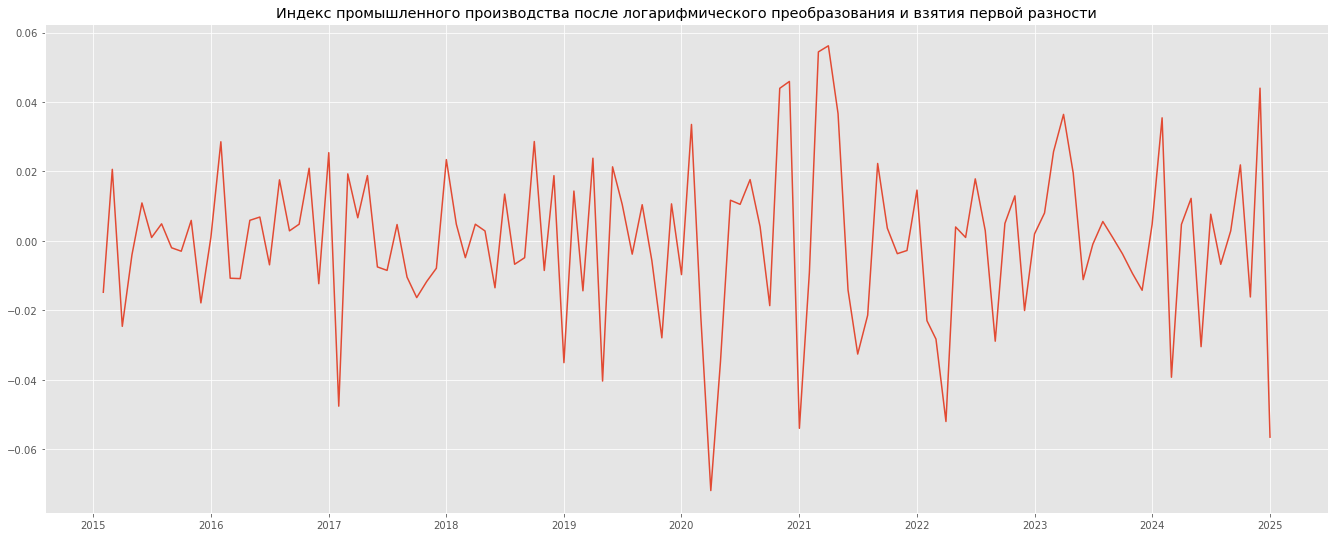

In [26]:
plt.plot(idx, ipi)
plt.title('Индекс промышленного производства после логарифмического преобразования и взятия первой разности')
plt.savefig('Ипп_после.png')

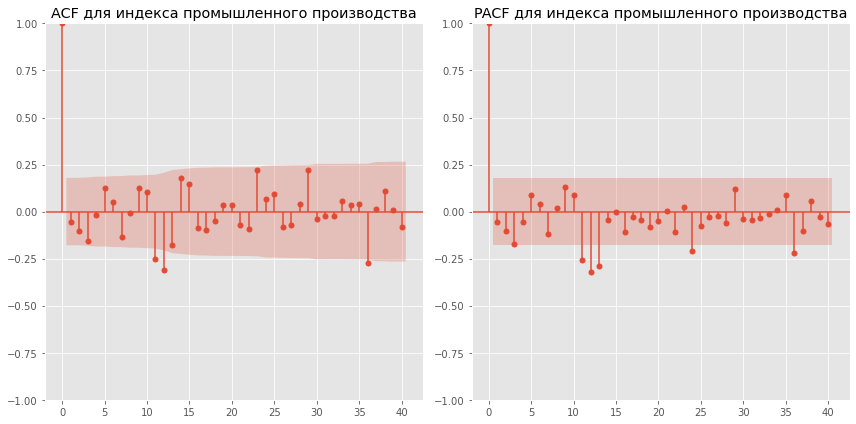

In [27]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sm.graphics.tsa.plot_acf(ipi[1:], lags=40, ax=plt.gca())
plt.title(f"ACF для индекса промышленного производства")
plt.subplot(1, 2, 2)
sm.graphics.tsa.plot_pacf(ipi[1:], lags=40, ax=plt.gca(), method='ywm')  
plt.title(f"PACF для индекса промышленного производства")
plt.tight_layout()
plt.show()

In [28]:
# ADF Test с констатой для IPI после логарифмической трансформации и взятия первой разности
result = adfuller(ipi[1:], regression = 'c',autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[1]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
#Отвергается нулевая гипотеза о наличии единичного корня на 1%, 5%, 10% уровнях значимости 

ADF Statistic: -5.641382055823062
n_lags: 1.034621087681477e-06
p-value: 1.034621087681477e-06
Critial Values:
   1%, -3.492995948509562
Critial Values:
   5%, -2.888954648057252
Critial Values:
   10%, -2.58139291903223


In [29]:
print(f'KPSS test, p-value: {sm.tsa.stattools.kpss(ipi[1:], regression = "c")[1]}')
#Нулевая гипотеза о стационарности процесса не отвергается на 1%, 5%, 10% уровнях значимости

KPSS test, p-value: 0.1


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


Итог: временной ряд для индекса промышленного производства был приведен к стационарному виду, что показали тесты Дикки-Фуллера и KPSS. Однако на графиках временного ряда, ACF и PACF видно присутствие сезонности (пики около 12 лага). Но дальнейшие преобразования могут привести к потере информации о природе данных, поэтому наличие сезонности будет учтено при помощи включения дамми переменных.

Приведение к стационарному виду ряда - M2

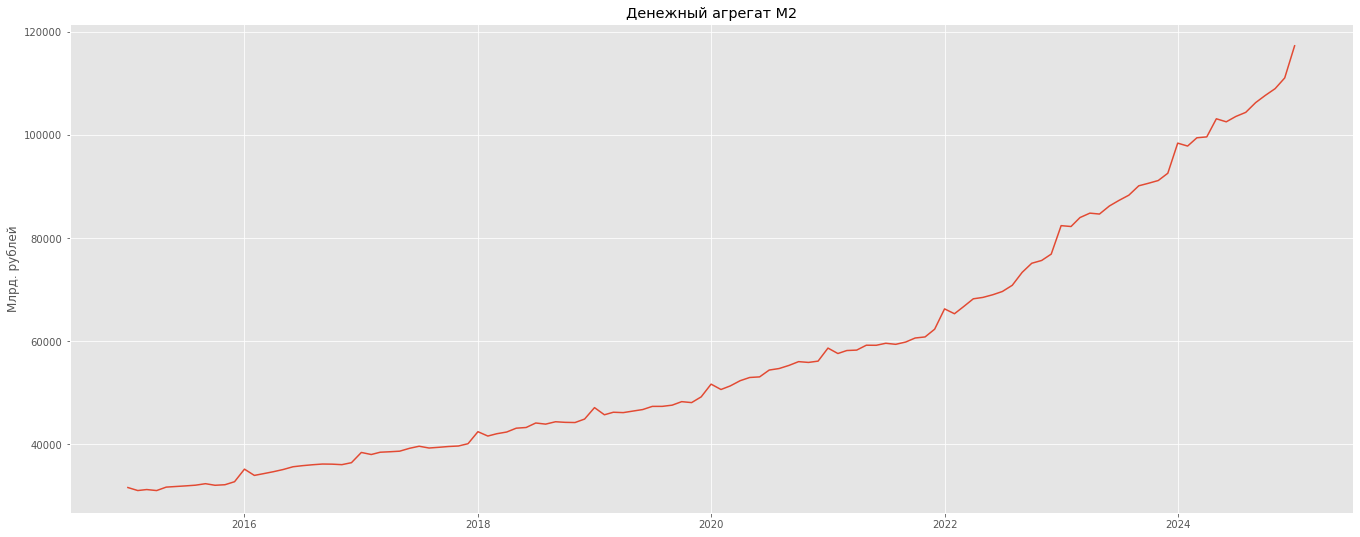

In [30]:
plt.plot(idx, data['М2'])
plt.title('Денежный агрегат М2')
plt.ylabel('Млрд. рублей')
plt.savefig('М2_до.png')

In [31]:
m2 = np.log(1 + data['М2'])

Text(0.5, 1.0, 'Денежный агрегат М2 после логарифмической трансформации')

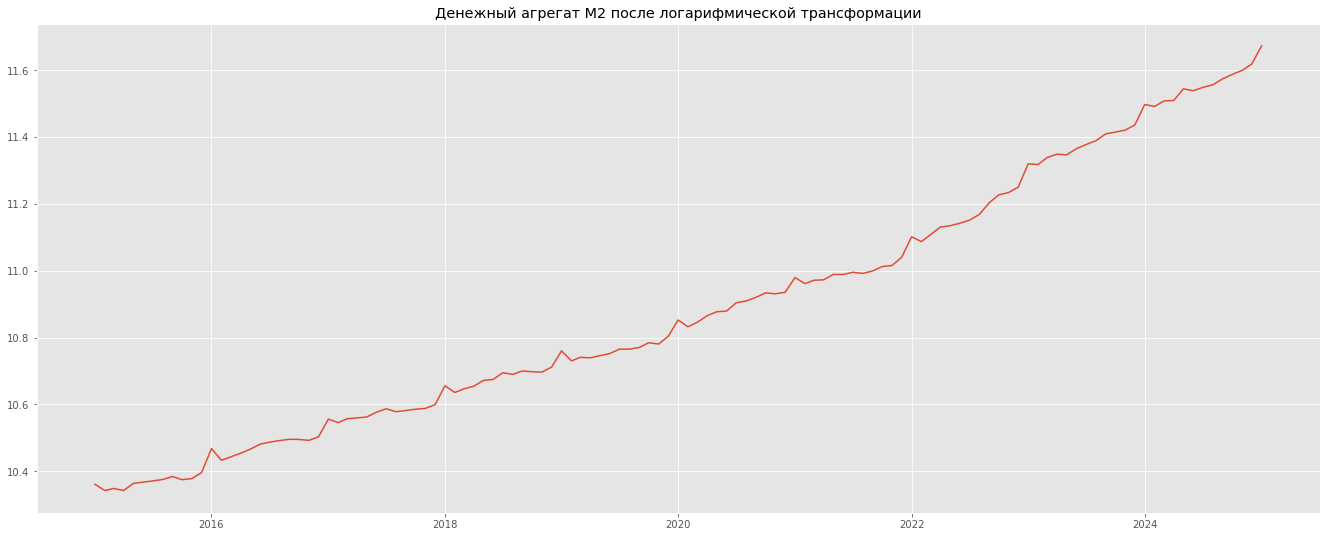

In [32]:
plt.plot(idx, m2)
plt.title('Денежный агрегат М2 после логарифмической трансформации')

Text(0.5, 1.0, 'Денежный агрегат M2 после удаления трендовой компоненты и логарифмирования')

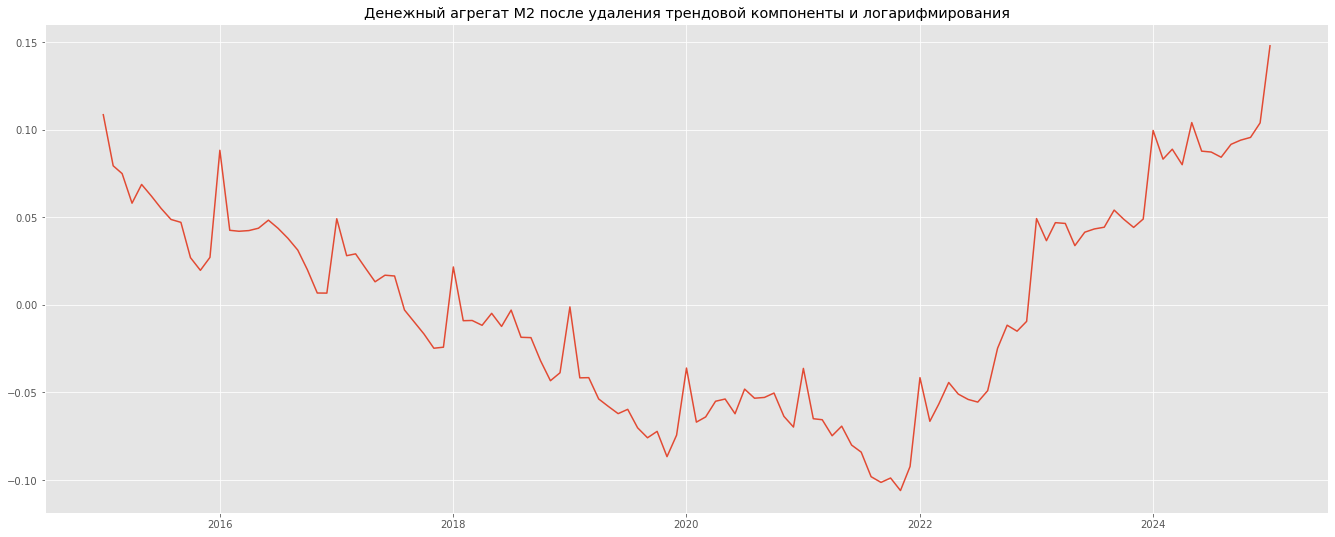

In [33]:
from scipy import signal
m2_detrended = signal.detrend(m2.values)
plt.plot(idx, m2_detrended)
plt.title('Денежный агрегат M2 после удаления трендовой компоненты и логарифмирования')

In [34]:
#Взятие первой разности для временного ряда M2 для приведения его к стационарному виду
m2_n = pd.Series(m2_detrended).diff(1)

Text(0.5, 1.0, 'Денежный агрегат M2 после удаления трендовой компоненты, логарифмирования и первой разности')

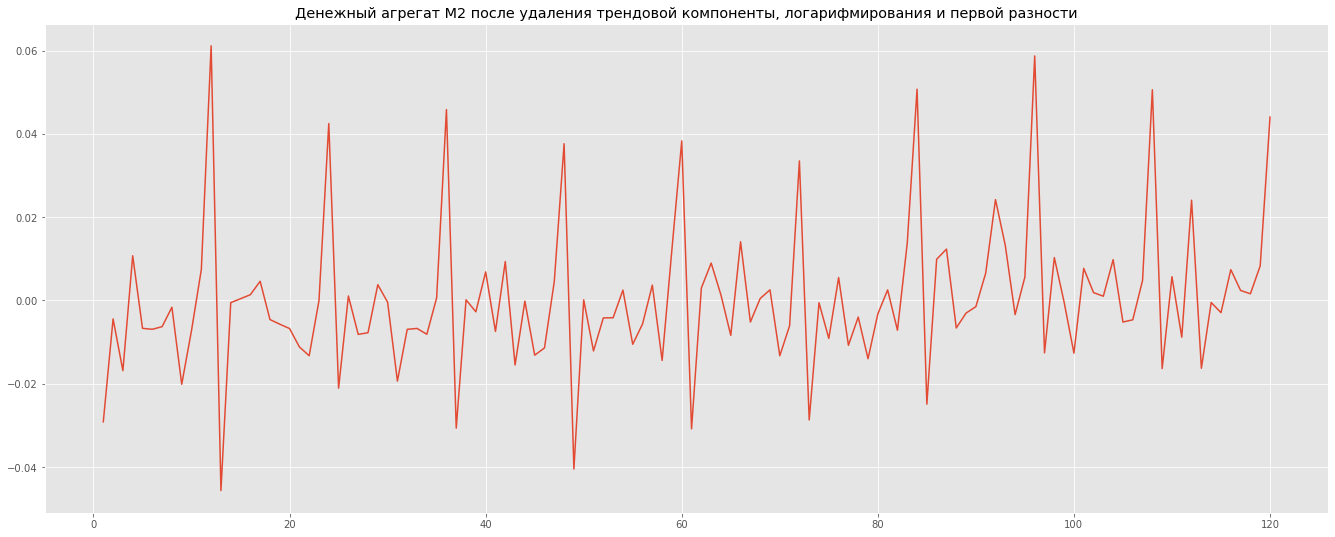

In [35]:
plt.plot(m2_n)
plt.title('Денежный агрегат M2 после удаления трендовой компоненты, логарифмирования и первой разности')

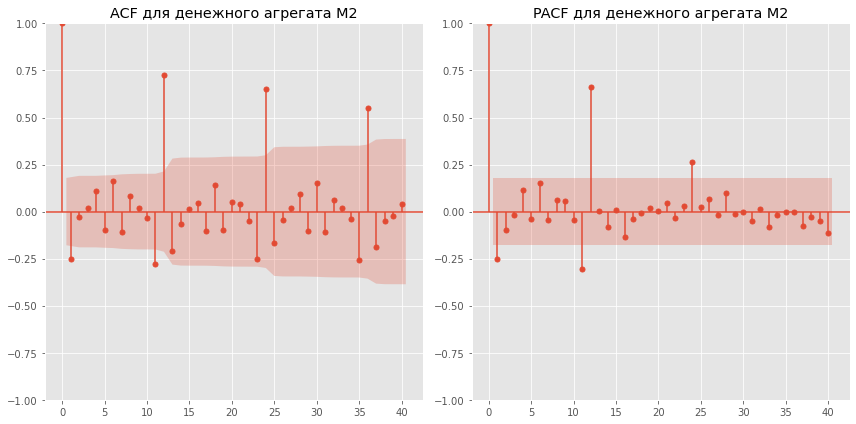

In [36]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sm.graphics.tsa.plot_acf(m2_n[1:], lags=40, ax=plt.gca())
plt.title(f"ACF для денежного агрегата M2")
plt.subplot(1, 2, 2)
sm.graphics.tsa.plot_pacf(m2_n[1:], lags=40, ax=plt.gca(), method='ywm')  
plt.title(f"PACF для денежного агрегата M2")
plt.tight_layout()
plt.show()

In [37]:
# ADF Test с констатой для M2 после логарифмической трансформации, взятия первой разности, удаления трендовой и сезонной компонент
result = adfuller(m2_n[1:], regression = 'c',autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[1]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
#Отвергается нулевая гипотеза о наличии единичного корня на 5%, 10% уровнях значимости 

ADF Statistic: -0.9850142400384982
n_lags: 0.758690697594806
p-value: 0.758690697594806
Critial Values:
   1%, -3.4924012594942333
Critial Values:
   5%, -2.8886968193364835
Critial Values:
   10%, -2.5812552709190673


In [38]:
print(f'KPSS test, p-value: {sm.tsa.stattools.kpss(m2_n[1:], regression = "c")[1]}')
#Нулевая гипотеза о стационарности процесса отвергается на 5%, 10% уровнях значимости

KPSS test, p-value: 0.01


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:2018: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  warnings.warn(


In [39]:
# удаление сезонной компоненты путем взятия разности
m2_n = m2_n.diff(12) 

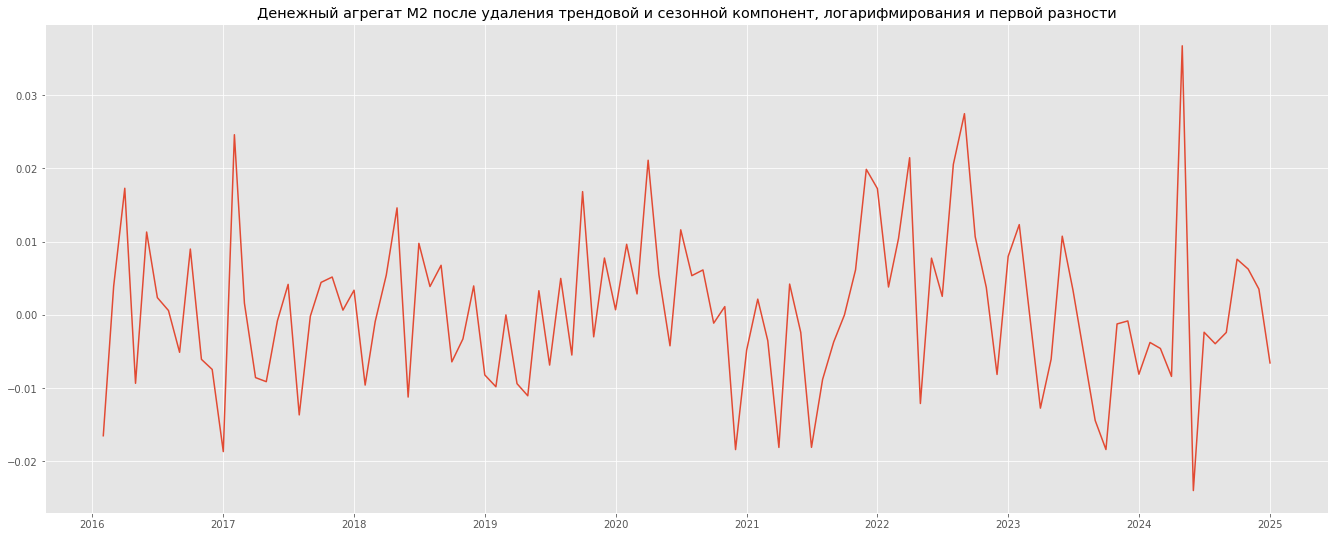

In [40]:
plt.plot(idx, m2_n)
plt.title('Денежный агрегат M2 после удаления трендовой и сезонной компонент, логарифмирования и первой разности')
plt.savefig('М2_после.png')

In [41]:
# ADF Test с констатой для M2 после логарифмической трансформации, взятия первой разности, удаления трендовой и сезонной компонент
result = adfuller(m2_n[13:], regression = 'c',autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[1]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
#Отвергается нулевая гипотеза о наличии единичного корня на 1%, 5%, 10% уровнях значимости 

ADF Statistic: -5.045507334155329
n_lags: 1.802287288412363e-05
p-value: 1.802287288412363e-05
Critial Values:
   1%, -3.5019123847798657
Critial Values:
   5%, -2.892815255482889
Critial Values:
   10%, -2.583453861475781


In [42]:
print(f'KPSS test, p-value: {sm.tsa.stattools.kpss(m2_n[13:], regression = "c")[1]}')
#Нулевая гипотеза о стационарности процесса не отвергается на 1%, 5%, 10% уровнях значимости

KPSS test, p-value: 0.1


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


Итог: к временному ряду денежного агрегата M2 была применена логарифмическая трансформация для устранения экспоненциального тренда и возможной гетероскедастичности. Далее была удалена трендовая компонента, однако в ряде сохранялась выраженная сезонность. Для её устранения была применена сезонная разность с лагом 12. Преобразованный ряд является стационарным как визуально, так и по результатам тестов KPSS и расширенного теста Дикки-Фуллера с константой. 

Приведение к стационарному виду ряда - валютного курса

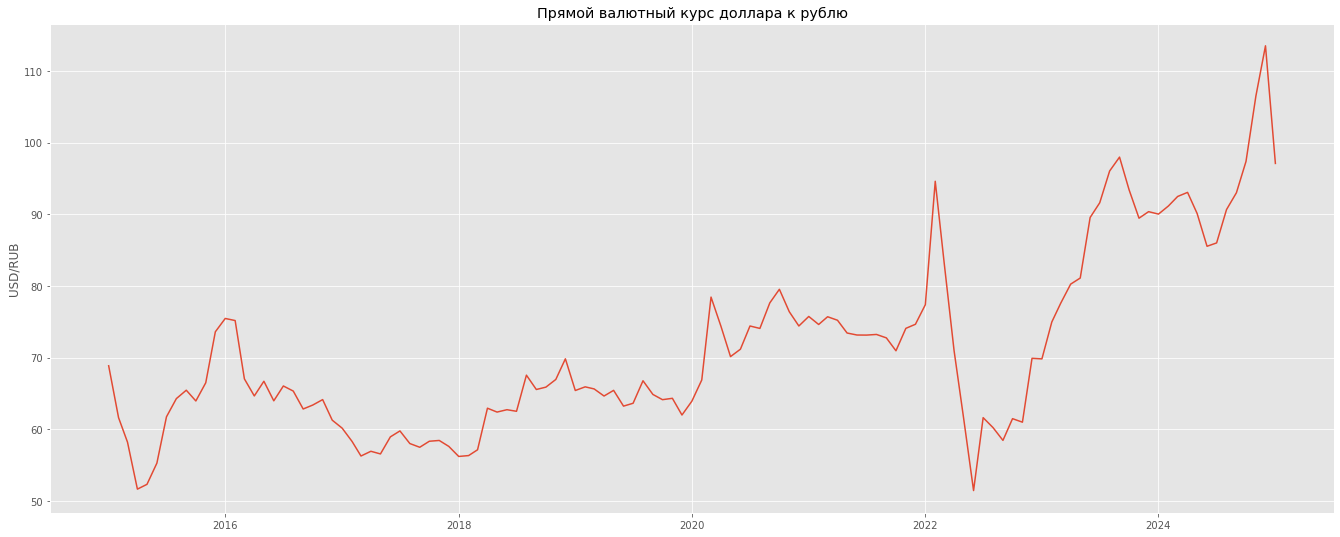

In [43]:
plt.plot(idx, data['exc_rate'])
plt.title('Прямой валютный курс доллара к рублю')
plt.ylabel('USD/RUB')
plt.savefig('валютный_курс_до.png')

In [44]:
exch_rate = np.log(1 + data['exc_rate'])

Text(0.5, 1.0, 'Прямой валютный курс доллара к рублю просле логарифмической трансформации')

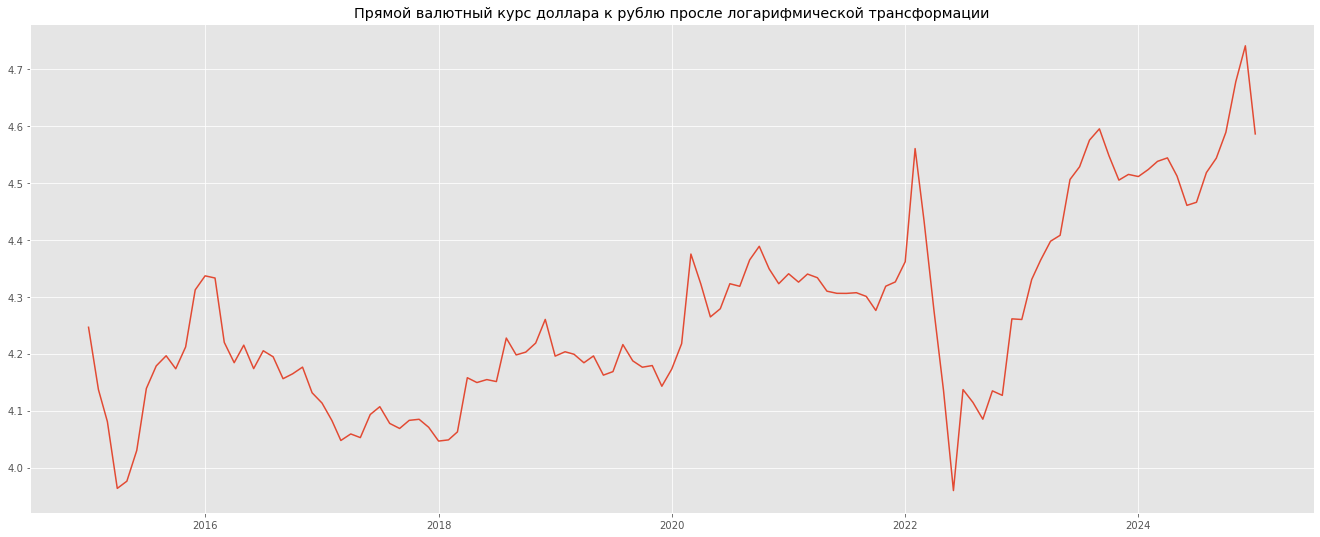

In [45]:
plt.plot(idx, exch_rate)
plt.title('Прямой валютный курс доллара к рублю просле логарифмической трансформации')

In [46]:
exch_rate = exch_rate.diff(1)

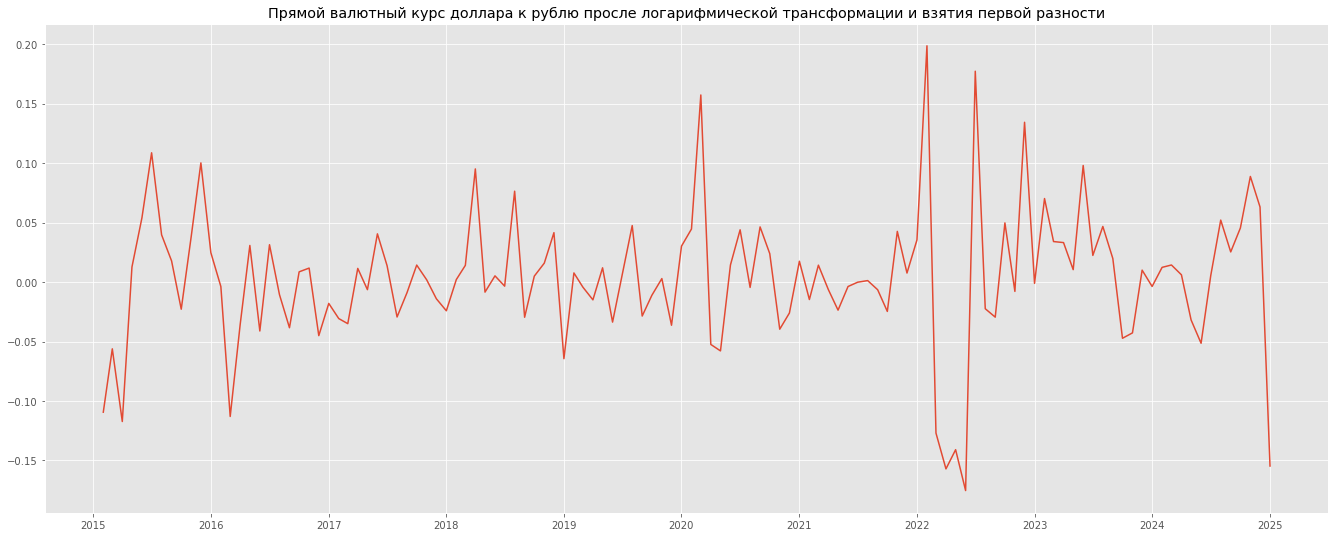

In [47]:
plt.plot(idx, exch_rate)
plt.title('Прямой валютный курс доллара к рублю просле логарифмической трансформации и взятия первой разности')
plt.savefig('валюта_после.png')

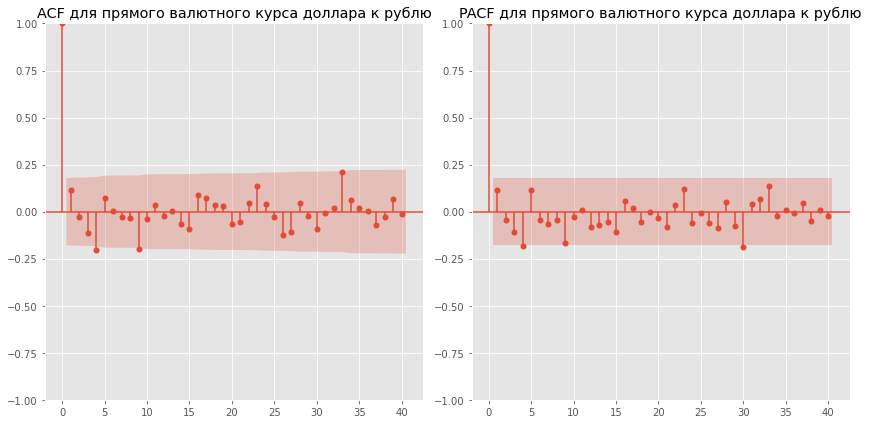

In [48]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sm.graphics.tsa.plot_acf(exch_rate[1:], lags=40, ax=plt.gca())
plt.title(f"ACF для прямого валютного курса доллара к рублю")
plt.subplot(1, 2, 2)
sm.graphics.tsa.plot_pacf(exch_rate[1:], lags=40, ax=plt.gca(), method='ywm')  
plt.title(f"PACF для прямого валютного курса доллара к рублю")
plt.tight_layout()
plt.show()

In [49]:
# ADF Test с констатой для валютного курса после логарифмической трансформации, взятия первой разности
result = adfuller(exch_rate[1:], regression = 'c',autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[1]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
#Отвергается нулевая гипотеза о наличии единичного корня на 1%, 5%, 10% уровнях значимости 

ADF Statistic: -9.393408687143818
n_lags: 6.469641233818897e-16
p-value: 6.469641233818897e-16
Critial Values:
   1%, -3.4865346059036564
Critial Values:
   5%, -2.8861509858476264
Critial Values:
   10%, -2.579896092790057


In [50]:
print(f'KPSS test, p-value: {sm.tsa.stattools.kpss(exch_rate[1:], regression = "c")[1]}')
#Нулевая гипотеза о стационарности процесса не отвергается на 1%, 5%, 10% уровнях значимости

KPSS test, p-value: 0.1


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


Итог: к временному ряду валютного курса была применена логарифмическая трансформация и взятие первой разности. После данных преобразований графики автокорреляционной (ACF) и частной автокорреляционной (PACF) функций не демонстрируют признаков сезонности, а коэффициенты быстро сходятся к нулю, что является косвенным признаком стационарности. Анализ временного ряда выявил наличие выбросов в начале 2022 и 2025 годов, что будет учтено в моделях с помощью дамми-переменных. Формальные статистические тесты KPSS и расширенный тест Дикки-Фуллера подтверждают стационарность процесса.

Приведение к стационарному виду ряда - инфляционных ожиданий фирм

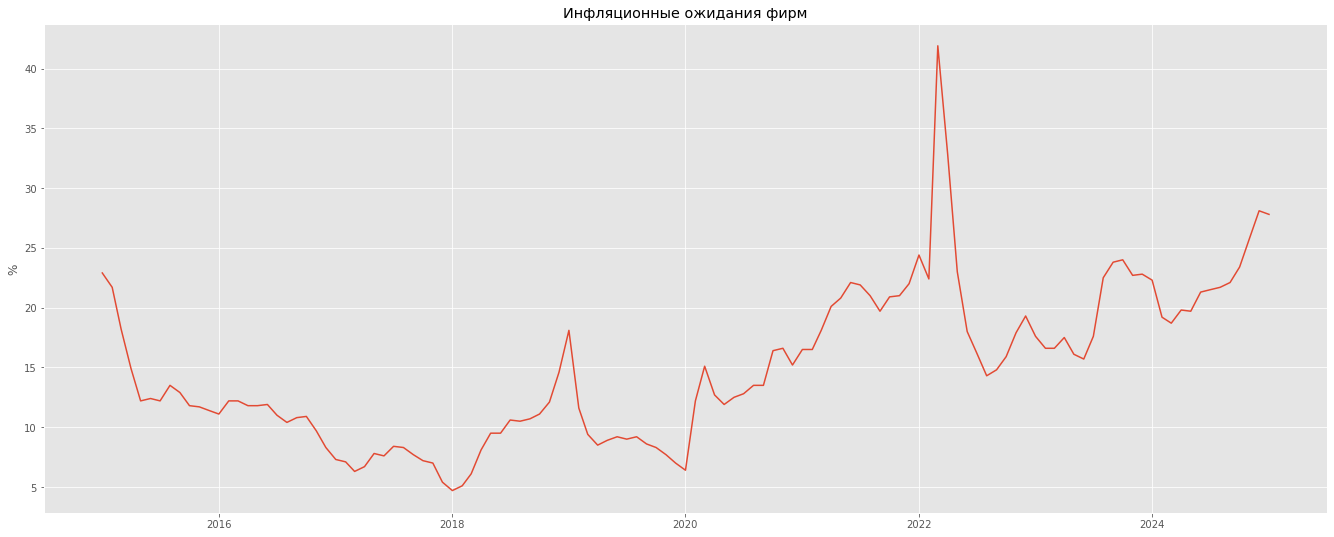

In [51]:
plt.plot(idx, data['Firms Inflation expectations'])
plt.title('Инфляционные ожидания фирм')
plt.ylabel('%')
plt.savefig('ожидания_до.png')

In [52]:
inf_exp = np.log(1 + data['Firms Inflation expectations'])

Text(0.5, 1.0, 'Инфляционные ожидания фирм после логарифмической трансформации')

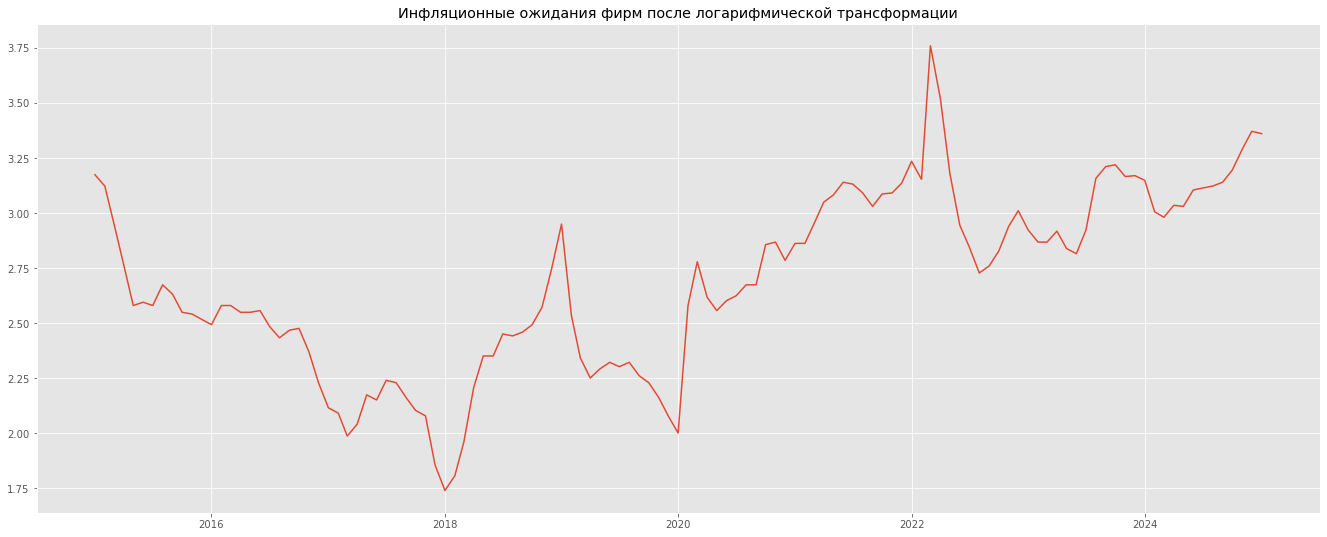

In [53]:
plt.plot(idx, inf_exp)
plt.title('Инфляционные ожидания фирм после логарифмической трансформации')

Text(0.5, 1.0, 'Инфляционные ожидания фирм после логарифмической трансформации и удаления трендовой компоненты')

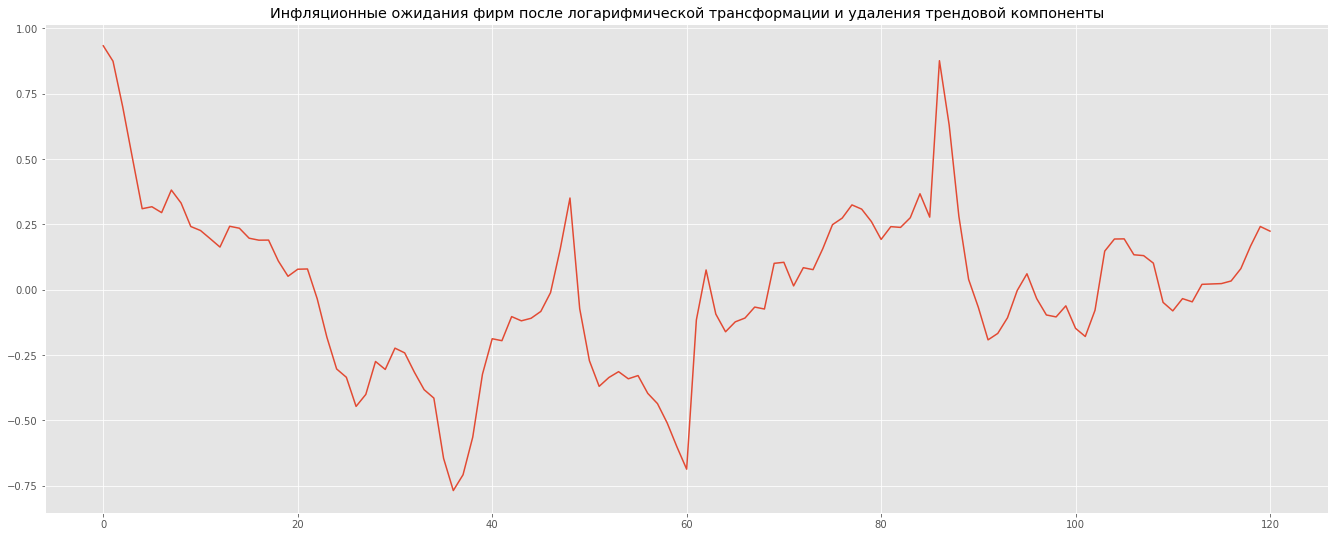

In [54]:
from scipy import signal
inf_exp_d = signal.detrend(inf_exp.values)
plt.plot(inf_exp_d)
plt.title('Инфляционные ожидания фирм после логарифмической трансформации и удаления трендовой компоненты')

In [55]:
inf_exp_d = pd.Series(inf_exp_d).diff(1)

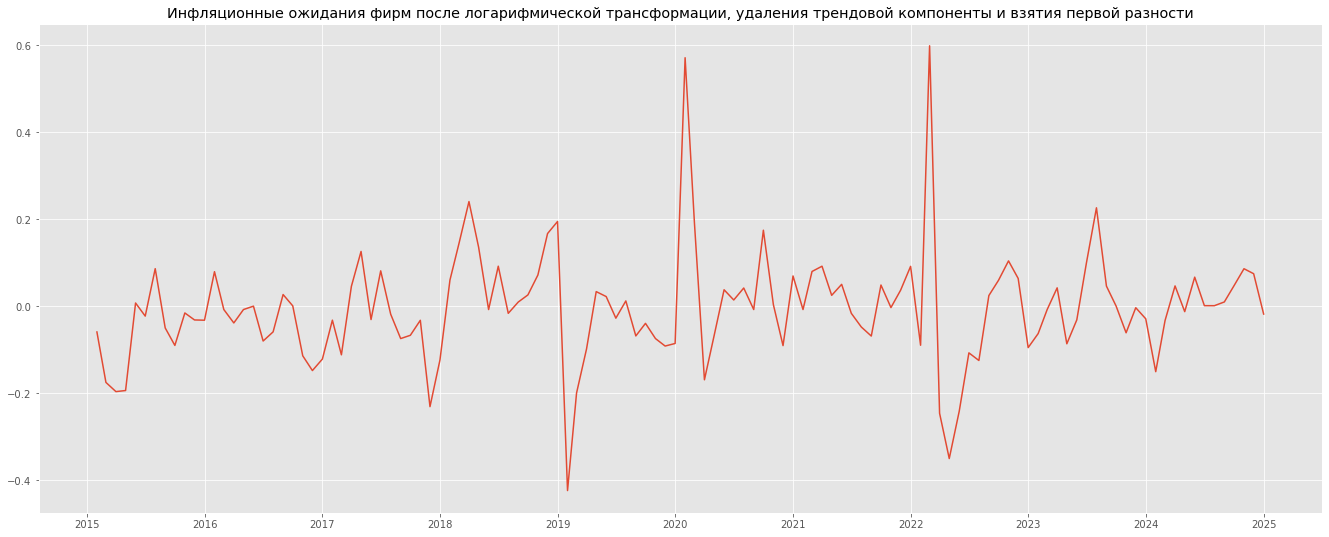

In [56]:
plt.plot(idx, inf_exp_d)
plt.title('Инфляционные ожидания фирм после логарифмической трансформации, удаления трендовой компоненты и взятия первой разности')
plt.savefig('ожидания_после.png')

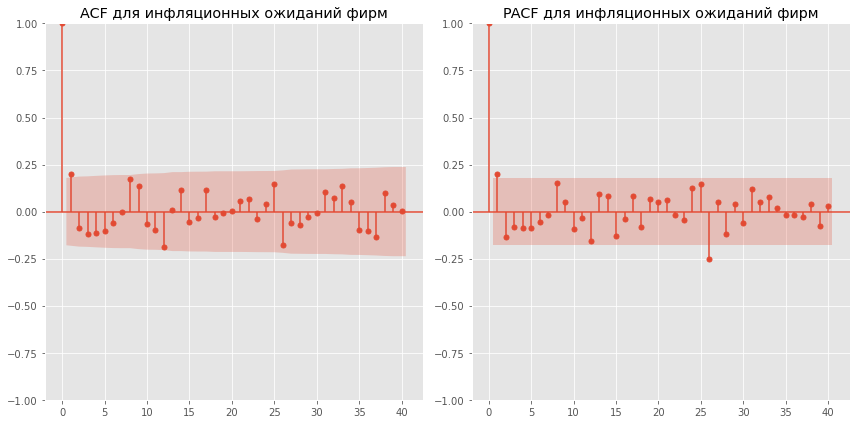

In [57]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sm.graphics.tsa.plot_acf(inf_exp_d[1:], lags=40, ax=plt.gca())
plt.title(f"ACF для инфляционных ожиданий фирм")
plt.subplot(1, 2, 2)
sm.graphics.tsa.plot_pacf(inf_exp_d[1:], lags=40, ax=plt.gca(), method='ywm')  
plt.title(f"PACF для инфляционных ожиданий фирм")
plt.tight_layout()
plt.show()

In [58]:
# ADF Test с констатой для инфляционных ожиданий фирм после логарифмической трансформации, взятия первой разности и удаления трендовой компоненты
result = adfuller(inf_exp_d[1:], regression = 'c',autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[1]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
#Отвергается нулевая гипотеза о наличии единичного корня на 1%, 5%, 10% уровнях значимости 

ADF Statistic: -7.8263238600308735
n_lags: 6.467208892963603e-12
p-value: 6.467208892963603e-12
Critial Values:
   1%, -3.4870216863700767
Critial Values:
   5%, -2.8863625166643136
Critial Values:
   10%, -2.580009026141913


In [59]:
print(f'KPSS test, p-value: {sm.tsa.stattools.kpss(inf_exp_d[1:], regression = "c")[1]}')
#Нулевая гипотеза о стационарности процесса не отвергается на 1%, 5%, 10% уровнях значимости

KPSS test, p-value: 0.1


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


Итог: по результатам тестов Дикки-Фуллера и KPSS можно сделать вывод, что после логарифмирования, устранения тренда и взятия первой разности временной ряд инфляционных ожиданий фирм является стационарным. Однако на графике временного ряда наблюдаются пики в начале 2019, 2020 и 2022 годов, что может указывать на наличие структурных изменений или аномалий в данных. Кроме того, график частной автокорреляционной функции (PACF) показывает наличие статистически значимого коэффициента на 24-м лаге. Однако дополнительные преобразования ряда могут привести к потере информации, поэтому для учета выбросов в модели будут добавлены дамми-переменные для соответствующих периодов.

Приведение к стационарному виду ряда - индекс волатильности российского рынка (RVI)

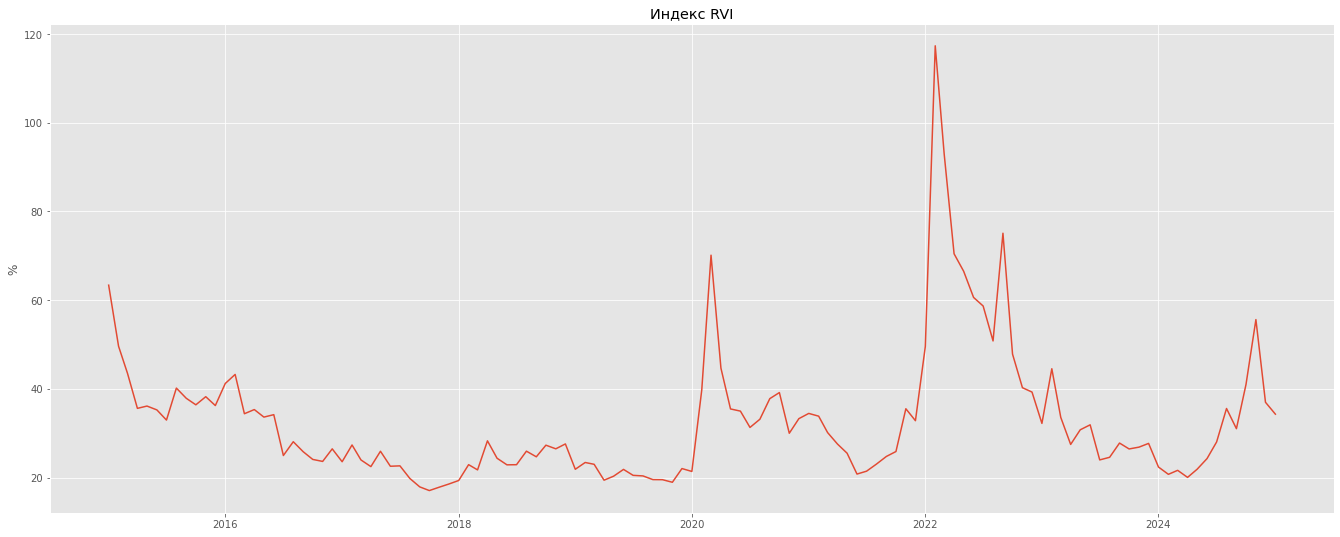

In [60]:
plt.plot(idx, data['RVI'])
plt.title('Индекс RVI')
plt.ylabel('%')
plt.savefig('rvi_до.png')

In [61]:
#Логарифмическая трансформация
rvi = np.log (1 + data['RVI'])

Text(0.5, 1.0, 'Индекс волатильности российского рынка (RVI) после логарифмической трансформации')

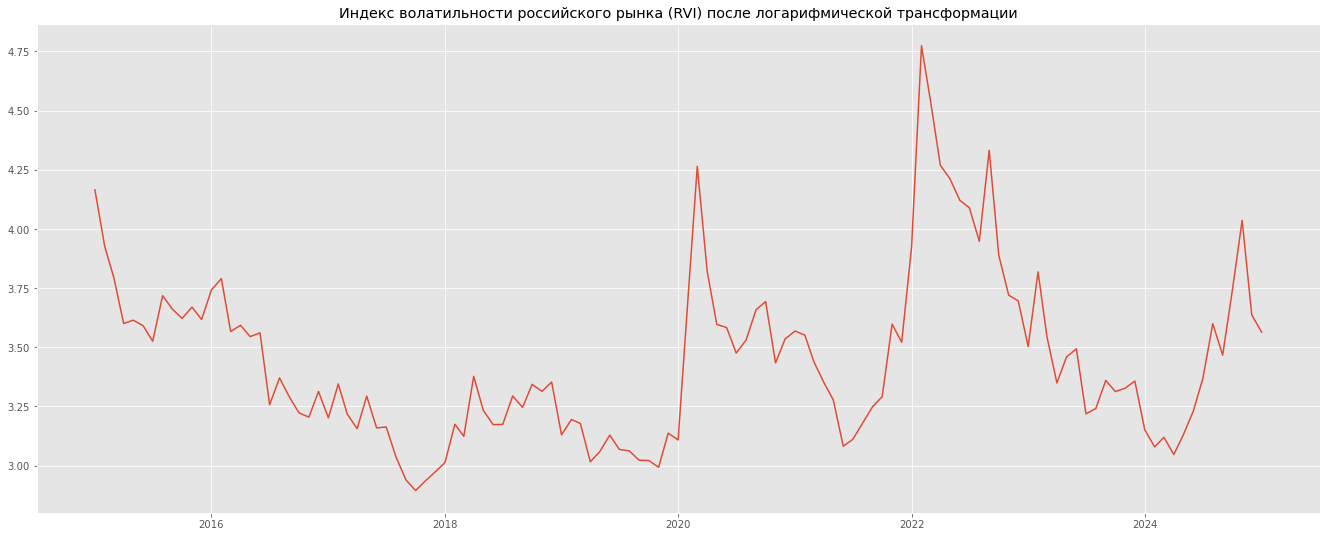

In [62]:
plt.plot(idx, rvi)
plt.title('Индекс волатильности российского рынка (RVI) после логарифмической трансформации')

In [63]:
#Взятие первой разности
rvi = rvi.diff(1)

Text(0.5, 1.0, 'Индекс волатильности российского рынка (RVI) после логарифмической трансформации и первой разности')

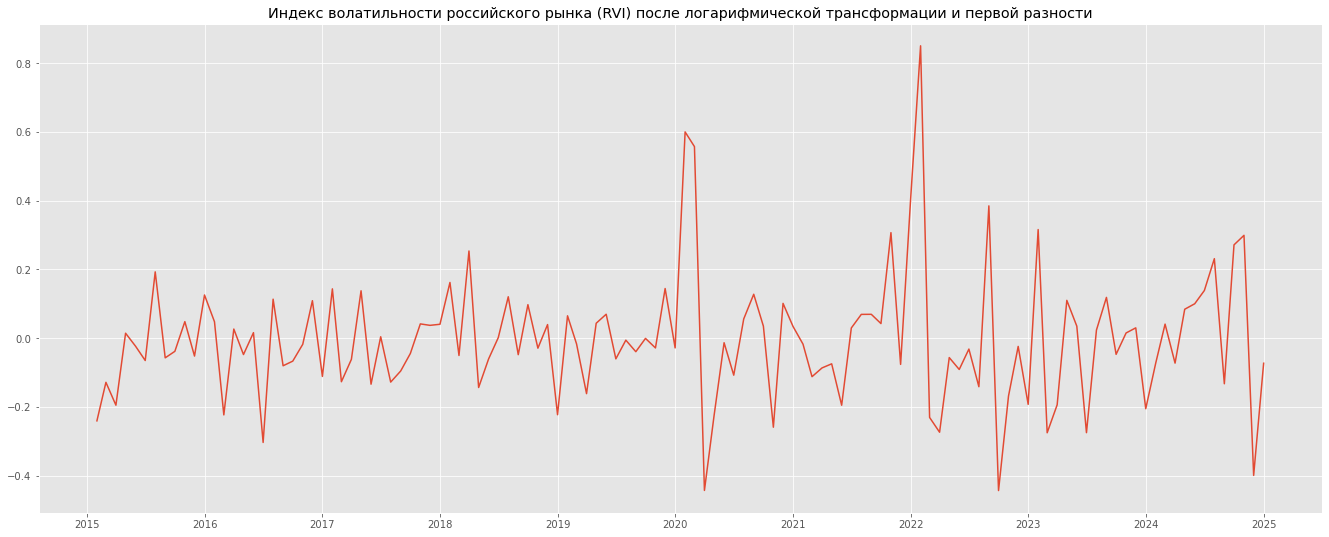

In [64]:
plt.plot(idx, rvi)
plt.title('Индекс волатильности российского рынка (RVI) после логарифмической трансформации и первой разности')

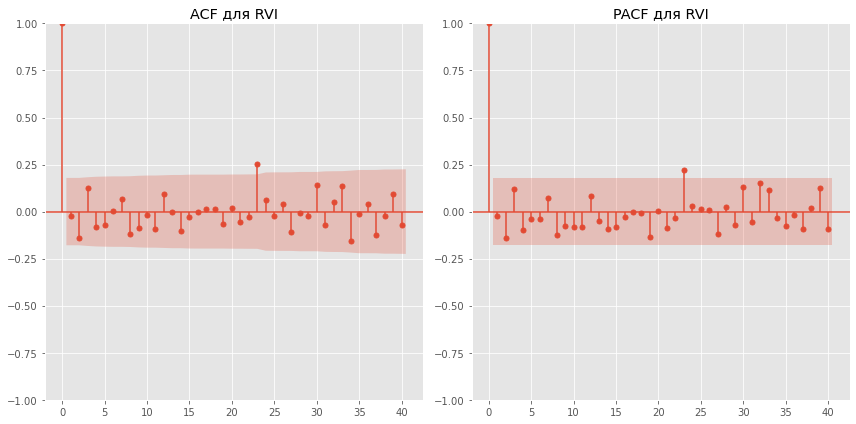

In [65]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sm.graphics.tsa.plot_acf(rvi[1:], lags=40, ax=plt.gca())
plt.title(f"ACF для RVI")
plt.subplot(1, 2, 2)
sm.graphics.tsa.plot_pacf(rvi[1:], lags=40, ax=plt.gca(), method='ywm')  
plt.title(f"PACF для RVI")
plt.tight_layout()
plt.show()

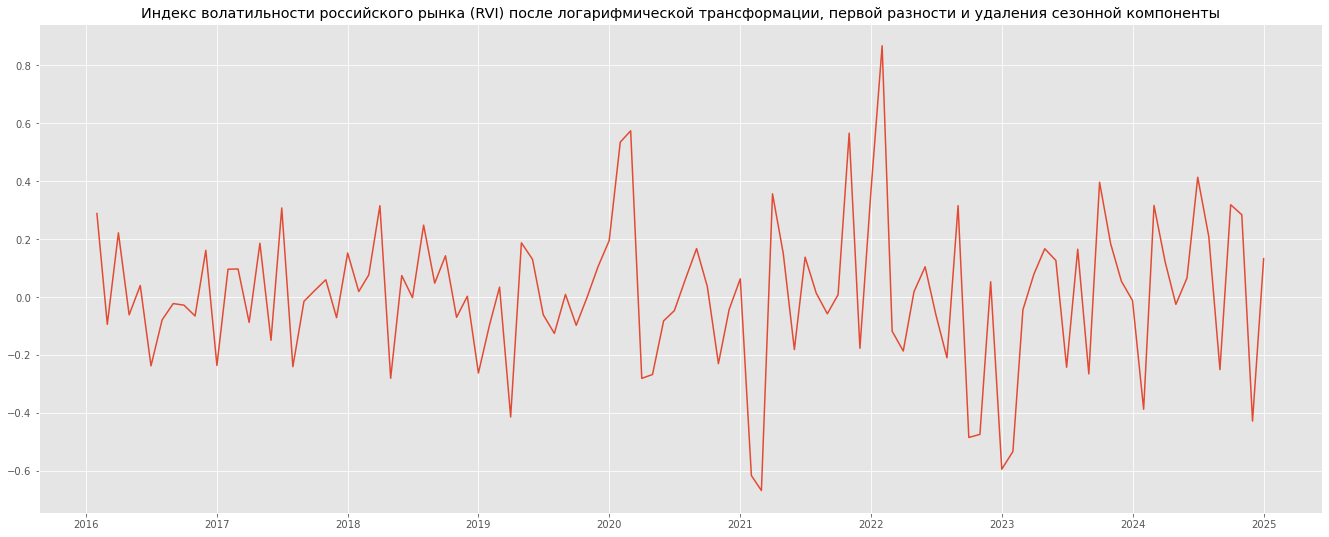

In [66]:
#Удаление сезонной компоненты, так как пик для 23 лага
rvi = rvi.diff(12)
plt.plot(idx, rvi)
plt.title('Индекс волатильности российского рынка (RVI) после логарифмической трансформации, первой разности и удаления сезонной компоненты')
plt.savefig('rvi_после.png')

In [67]:
# ADF Test с констатой для RVI после логарифмической трансформации, взятия первой разности и удаления сезонной компоненты
result = adfuller(rvi[13:], regression = 'c',autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'n_lags: {result[1]}')
print(f'p-value: {result[1]}')
for key, value in result[4].items():
    print('Critial Values:')
    print(f'   {key}, {value}')
#Отвергается нулевая гипотеза о наличии единичного корня на 1%, 5%, 10% уровнях значимости 

ADF Statistic: -5.7845855582967305
n_lags: 5.033884278906331e-07
p-value: 5.033884278906331e-07
Critial Values:
   1%, -3.5003788874873405
Critial Values:
   5%, -2.8921519665075235
Critial Values:
   10%, -2.5830997960069446


In [68]:
print(f'KPSS test, p-value: {sm.tsa.stattools.kpss(rvi[13:], regression = "c")[1]}')
#Нулевая гипотеза о стационарности процесса не отвергается на 1%, 5%, 10% уровнях значимости

KPSS test, p-value: 0.1


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\stattools.py:2022: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  warnings.warn(


Итог: временной ряд RVI был приведен к стационарному виду с помощью логарифмической трансформации, взятия первой разности и удаления сезонной компоненты путем взятия сезонной разности с лагом 12. Результаты тестов KPSS и Дикки-Фуллера подтверждают стационарность преобразованного ряда. Однако на графике временного ряда наблюдаются значительные пики в начале 2020, 2021, 2022 и 2023 годов, что может свидетельствовать о структурных изменениях или выбросах. Для их учета в спецификацию модели будут добавлены дамми-переменные.

In [69]:
df = pd.DataFrame({'Date': data['Date'], 'CPI': data['CPI'], 'IPI': ipi, 'M2': m2_n, 'Exchange_rate': exch_rate, 'Inflation_expectations': inf_exp_d, 'RVI': rvi})
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date') 

In [70]:
#Поскольку для приведения временных рядов к стационарному виду брались разности, то число наблюдений сократилось
df = df.iloc[13:]
df

,CPI,IPI,M2,Exchange_rate,Inflation_expectations,RVI
Date,,,,,,
2016-02-01,100.63,0.028559,-0.016508,-0.003800,0.079546,0.288131
2016-03-01,100.46,-0.010737,0.003912,-0.113019,-0.007466,-0.094739
2016-04-01,100.44,-0.010854,0.017282,-0.035611,-0.038237,0.221431
2016-05-01,100.41,0.005935,-0.009350,0.030749,-0.007466,-0.062031
2016-06-01,100.36,0.006880,0.011307,-0.041161,0.000316,0.039474
...,...,...,...,...,...,...
2024-09-01,100.48,0.002892,-0.002401,0.025318,0.010002,-0.251128
2024-10-01,100.75,0.021895,0.007592,0.045441,0.047285,0.318385
2024-11-01,101.43,-0.016137,0.006250,0.088755,0.086353,0.283928


In [71]:
df['seasonal_dummies'] = 0.001
df.loc[df.index.isin(['2022-03-01', '2021-03-01', '2022-02-01']), 'seasonal_dummies'] = 1 

# Разбиение выборки на обучающую и тестовую + кросс-валидация с расширябщимся окном. Определение количества лагов в VAR-модели

In [72]:
train_size = int(len(df) * 0.7) 
X_train, X_test = df[:train_size].drop(columns = ['CPI']), df[train_size:].drop(columns = ['CPI'])
y_train, y_test = df['CPI'][:train_size], df['CPI'][train_size:]

In [73]:
print(f'Число наблюдений в обучающей выборке: {len(X_train)}, число наблюдений в тестовой выборке: {len(X_test)}')

Число наблюдений в обучающей выборке: 75, число наблюдений в тестовой выборке: 33


In [74]:
train_df = X_train.copy()
train_df.loc[:, 'CPI'] = y_train
train_df

,IPI,M2,Exchange_rate,Inflation_expectations,RVI,seasonal_dummies,CPI
Date,,,,,,,
2016-02-01,0.028559,-0.016508,-0.003800,0.079546,0.288131,0.001,100.63
2016-03-01,-0.010737,0.003912,-0.113019,-0.007466,-0.094739,0.001,100.46
2016-04-01,-0.010854,0.017282,-0.035611,-0.038237,0.221431,0.001,100.44
2016-05-01,0.005935,-0.009350,0.030749,-0.007466,-0.062031,0.001,100.41
2016-06-01,0.006880,0.011307,-0.041161,0.000316,0.039474,0.001,100.36
...,...,...,...,...,...,...,...
2021-12-01,-0.002761,0.019867,0.007563,0.036986,-0.177431,0.001,100.82
2022-01-01,0.014639,0.017235,0.035451,0.091789,0.368661,0.001,100.99
2022-02-01,-0.022968,0.003798,0.198604,-0.089479,0.867560,1.000,101.17


In [75]:
from statsmodels.tsa.api import VAR
model = VAR(train_df[['IPI', 'M2', 'Exchange_rate', 'Inflation_expectations', 'RVI','CPI']])
result = model.select_order(maxlags = 5)
print(result.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -30.35     -30.16*   6.587e-14      -30.27
1     -30.97*      -29.62  3.550e-14*     -30.44*
2      -30.78      -28.27   4.406e-14      -29.78
3      -30.53      -26.87   5.990e-14      -29.08
4      -30.34      -25.52   8.111e-14      -28.43
5      -30.25      -24.27   1.087e-13      -27.87
-------------------------------------------------


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Заметим, что AIC, BIC принимают отрицательные значения, что показывает высокое значение функции правдоподобия, а значит, и хорошую подгонку под данные модели. Наименьшие значения для информационных критериев AIC, HQIC, FPE получаются при 1 лаге, а для BIC при отсутствии лагов. В целях балансировки точности прогнозирования и сложности модели, в спецификации VAR-модели будет использован первый лаг всех переменных, что делает его оптимальным порядком модели

In [76]:
from statsmodels.tsa.statespace.varmax import VARMAX
var_model = VARMAX(train_df[['IPI', 'M2', 'Exchange_rate', 'Inflation_expectations', 'RVI','CPI']], order = (1,0), exog = train_df['seasonal_dummies'], enforce_stationarity = True)
fitted_model = var_model.fit(disp = False)
fitted_model.summary()

C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Dep. Variable:,"['IPI', 'M2', 'Exchange_rate', 'Inflation_expectations', 'RVI', 'CPI']",No. Observations:,75
Model:,VARX(1),Log Likelihood,562.733
,+ intercept,AIC,-987.465
Date:,"Tue, 04 Mar 2025",BIC,-827.559
Time:,04:23:25,HQIC,-923.617
Sample:,02-01-2016,,
,- 04-01-2022,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"0.22, 0.02, 0.04, 0.03, 0.18, 0.75",Jarque-Bera (JB):,"0.47, 0.57, 5.67, 42.77, 2.19, 8.03"
Prob(Q):,"0.64, 0.90, 0.84, 0.85, 0.67, 0.39",Prob(JB):,"0.79, 0.75, 0.06, 0.00, 0.33, 0.02"
Heteroskedasticity (H):,"2.61, 0.84, 2.49, 2.64, 2.12, 2.31",Skew:,"-0.15, 0.20, -0.28, 0.29, -0.37, 0.05"


При оценке модели VARX(1) оптимизация максимального правдоподобия не сходилась. Это может быть связано с недостаточным количеством наблюдений при большом числе эндогенных переменных, а также с включением экзогенных переменных. Такой результат является негативным сигналом, указывающим на возможную проблему перепараметризации и нестабильность оценок.

In [77]:
model_fitted = model.fit(1)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 04, Mar, 2025
Time:                     04:23:25
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -29.6105
Nobs:                     74.0000    HQIC:                  -30.3966
Log likelihood:           555.966    FPE:                3.74852e-14
AIC:                     -30.9182    Det(Omega_mle):     2.17942e-14
--------------------------------------------------------------------
Results for equation IPI
                               coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------
const                             0.894723         0.382039            2.342           0.019
L1.IPI                           -0.001874         0.123075           -0.015           0.988
L1.M2         

In [78]:
model_fitted.resid

,IPI,M2,Exchange_rate,Inflation_expectations,RVI,CPI
Date,,,,,,
2016-03-01,-0.002913,0.001437,-0.109418,-0.038838,-0.143521,-0.179810
2016-04-01,-0.018906,0.020779,-0.054671,0.125807,0.212402,1.067035
2016-05-01,0.007403,-0.010666,0.010063,0.034030,-0.120187,-0.025799
2016-06-01,0.007328,0.010364,-0.024789,-0.043143,0.057721,-0.304541
2016-07-01,-0.010100,0.003865,0.003567,-0.038477,-0.330765,0.422565
...,...,...,...,...,...,...
2021-12-01,0.015049,0.011309,0.023245,-0.044203,-0.199006,-0.842295
2022-01-01,0.012245,0.017296,0.022068,0.084055,0.295315,0.413367
2022-02-01,-0.011266,-0.001446,0.181767,-0.174399,0.733075,-0.156436


Ljung-Box test проверяет наличие автокорреляции у временного ряда. Нулевая гипотеза: остатки независимо распределены. Альтернативная гипотеза: остатки не являются независимо распределенными, они содержат серийную корреляцию. Данный тест проверяет, ведут ли себя остатки как белый шум, что является важным требованием для корректного прогнозирования. Это также показывает адекватность выбранной модели.

In [79]:
sm.stats.acorr_ljungbox(model_fitted.resid['CPI'], lags = 12, return_df = True)

,lb_stat,lb_pvalue
1,1.673089,0.195845
2,1.714329,0.424364
3,2.247425,0.522668
4,2.748446,0.600764
5,2.945353,0.708411
6,4.469317,0.613436
7,4.687929,0.697985
8,4.715346,0.787522
9,4.715999,0.858329
10,4.716467,0.909296


Вывод: нулевая гипотеза об отсутствии автокорреляции для ряда ИПЦ не отвергается на 1%, 5%, 10% уровнях значимости для всех 12 лагов. Кроме того, отсутствие автокорреляции наблюдается и для всех других используемых временных рядов (M2, Exchange_rate, Inflation_expectations), что показывает адекватность модели.

In [92]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=6)

rmse_scores = []  
mape_scores = []
predictions_var = []

for train_idx, test_idx in tscv.split(df[['IPI', 'M2', 'Exchange_rate', 'Inflation_expectations', 'RVI', 'CPI']]):
    train, test = df[['IPI', 'M2', 'Exchange_rate', 'Inflation_expectations', 'RVI', 'CPI']].iloc[train_idx], df[['IPI', 'M2', 'Exchange_rate', 'Inflation_expectations', 'RVI', 'CPI']].iloc[test_idx]  
    model = VAR(train)
    results = model.fit(1, trend='n') 

    test_pred = pd.DataFrame(results.forecast(train.values[-1:], steps=len(test)), columns=['IPI', 'M2', 'Exchange_rate', 'Inflation_expectations', 'RVI', 'CPI'])
    
    rmse = np.sqrt(mean_squared_error(test['CPI'], test_pred['CPI']))
    rmse_scores.append(rmse)
    print(f"Split {len(rmse_scores)} - VAR RMSE: {rmse:.4f}")
    mape =  np.mean(np.abs((np.array(test['CPI'])  - np.array(test_pred['CPI']))/ np.array(test_pred['CPI']))) * 100
    mape_scores.append(mape)
    print(f"Split {len(mape_scores)} - VAR MAPE: {mape:.4f}")

    predictions_var.extend(test_pred['CPI'])

print(f'Средний RMSE по кросс-валидации: {np.mean(rmse_scores):.4f}')
print(f'Средний MAPE по кросс-валидации: {np.mean(mape_scores):.4f}')  

Split 1 - VAR RMSE: 1.2323
Split 1 - VAR MAPE: 1.0223
Split 2 - VAR RMSE: 0.2742
Split 2 - VAR MAPE: 0.2421
Split 3 - VAR RMSE: 0.6276
Split 3 - VAR MAPE: 0.5692
Split 4 - VAR RMSE: 0.2852
Split 4 - VAR MAPE: 0.2614
Split 5 - VAR RMSE: 0.8400
Split 5 - VAR MAPE: 0.6832
Средний RMSE по кросс-валидации: 0.6518
Средний MAPE по кросс-валидации: 0.5556


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

Проделав предобработку данных для повышения стационарности рядов, мы подошли близко к предпосылкам, необходимым для моделирования с помощью VAR, AR, ARIMA. Здесь мы смотрим, есть ли статистическая разница между результатами бенчмарк-моделей (AR(1), ARIMA и наивный прогноз) и результатами более продвинутых моделей (RF, XGboost, GradientBoosting, MLP, SVM) с помощью DM-теста.

In [91]:
def benchmark_baseline_models(df):
    tscv = TimeSeriesSplit(n_splits=5, test_size=6)

    predictions_naive = []
    predictions_ar = []
    predictions_arima = []
    actual_values = []

    for train_index, test_index in tscv.split(df):
        train, test = df.iloc[train_index], df.iloc[test_index]
        y_train, y_test = train['CPI'], test['CPI']
        actual_values.extend(y_test)

        #наивная модель
        y_pred_naive = np.repeat(y_train.iloc[-1], len(y_test))
        predictions_naive.extend(y_pred_naive)

        # AR(1)
        model_ar = AutoReg(y_train, lags=1)
        model_ar_fitted = model_ar.fit()
        y_pred_ar = model_ar_fitted.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)
        predictions_ar.extend(y_pred_ar)

        #  ARIMA
        model_arima = auto_arima(y_train, seasonal=False, trace=False, error_action='ignore', suppress_warnings=True)
        y_pred_arima = model_arima.predict(n_periods=len(y_test))
        predictions_arima.extend(y_pred_arima)

    return predictions_naive, predictions_ar, predictions_arima, actual_values



def time_series_cv_with_metrics(df, features, target, model, n_splits=5):
    df = df.dropna()

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=6)  

    predictions = []  
    actual_values = []

    for train_index, test_index in tscv.split(df):
        train, test = df.iloc[train_index], df.iloc[test_index]

        X_train, y_train = train[features], train[target]
        X_test, y_test = test[features], test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        predictions.extend(y_pred) 
        actual_values.extend(y_test)  
    return predictions, actual_values



def compare_models_with_dm_test(model1_name, model2_name, all_predictions, actual_lst, crit="MAPE"):
    pred1_lst = all_predictions[model1_name]
    pred2_lst = all_predictions[model2_name]
    
    if len(actual_lst) != len(pred1_lst) or len(actual_lst) != len(pred2_lst):
        raise ValueError("Lengths of actual_lst, pred1_lst, and pred2_lst do not match.")

    result = dm_test(actual_lst, pred1_lst, pred2_lst, crit=crit)   
    print(f'{model1_name} vs {model2_name} — DM test statistic: {result.DM:.4f}, p-value: {result.p_value:.4f}')



predictions_naive, predictions_ar, predictions_arima, actual_values = benchmark_baseline_models(df)

#собираем все прогнозы для моделей
all_predictions = {
    'Naive': predictions_naive,
    'AR(1)': predictions_ar,
    'ARIMA': predictions_arima,
    'VAR': predictions_var,
}

base_models = ['Naive', 'AR(1)', 'ARIMA']
for base_model in base_models:
    for big_model in all_predictions.keys():
        if base_model != big_model:
            compare_models_with_dm_test(base_model, big_model, all_predictions, actual_values)

models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'SVM': SVR(kernel='rbf'),
    'MLP': MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42),
    'GBR': GradientBoostingRegressor(n_estimators=100, random_state=42),
}
features = [col for col in df.columns if col != 'CPI']
target = 'CPI'
for model_name, model in models.items():
    predictions, _ = time_series_cv_with_metrics(df, features, target, model)
    all_predictions[model_name] = predictions

#сравнение всех моделей с использованием теста Диболда-Мариано
for model1 in all_predictions:
    for model2 in all_predictions:
        if model1 != model2:
            compare_models_with_dm_test(model1, model2, all_predictions, actual_values)


C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\deterministic.py:302: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Zorin\anaconda3\lib\site-packages\statsmodels\tsa\deterministic.py:302: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is se

Naive vs AR(1) — DM test statistic: 1.2498, p-value: 0.2214
Naive vs ARIMA — DM test statistic: 1.2600, p-value: 0.2177
Naive vs VAR — DM test statistic: -1.4399, p-value: 0.1606
AR(1) vs Naive — DM test statistic: -1.2498, p-value: 0.2214
AR(1) vs ARIMA — DM test statistic: 0.7805, p-value: 0.4414
AR(1) vs VAR — DM test statistic: -2.6111, p-value: 0.0141
ARIMA vs Naive — DM test statistic: -1.2600, p-value: 0.2177
ARIMA vs AR(1) — DM test statistic: -0.7805, p-value: 0.4414
ARIMA vs VAR — DM test statistic: -2.6252, p-value: 0.0137


C:\Users\Zorin\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Zorin\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Zorin\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Zorin\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Zorin\anaconda3\lib\site-packages\sklearn\neural_network\_multi

Naive vs AR(1) — DM test statistic: 1.2498, p-value: 0.2214
Naive vs ARIMA — DM test statistic: 1.2600, p-value: 0.2177
Naive vs VAR — DM test statistic: -1.4399, p-value: 0.1606
Naive vs RandomForest — DM test statistic: 0.6478, p-value: 0.5222
Naive vs XGBoost — DM test statistic: 0.2620, p-value: 0.7952
Naive vs SVM — DM test statistic: 0.6127, p-value: 0.5449
Naive vs MLP — DM test statistic: -5.5293, p-value: 0.0000
Naive vs GBR — DM test statistic: 0.2672, p-value: 0.7912
AR(1) vs Naive — DM test statistic: -1.2498, p-value: 0.2214
AR(1) vs ARIMA — DM test statistic: 0.7805, p-value: 0.4414
AR(1) vs VAR — DM test statistic: -2.6111, p-value: 0.0141
AR(1) vs RandomForest — DM test statistic: -1.3432, p-value: 0.1896
AR(1) vs XGBoost — DM test statistic: -1.9018, p-value: 0.0672
AR(1) vs SVM — DM test statistic: -1.4805, p-value: 0.1495
AR(1) vs MLP — DM test statistic: -5.8929, p-value: 0.0000
AR(1) vs GBR — DM test statistic: -1.5089, p-value: 0.1421
ARIMA vs Naive — DM test stat

Применен тест Диболда-Мариано для проверки статистической значимости различий в точности прогнозов бенчмарк-моделей с более сложными моделями в целях выяснить, оправдано ли использование более сложных моделей, если простые демонстрируют высокую предсказательную способность и нас устраивает их качество.Тест Диболда-Мариано показал, что на 5% уровне в большинстве
случаев различия в точности прогнозов между моделями-бенчмарками и ML-моделями не являются статистически значимыми. Это означает, что сложные модели не демонстрируют в общем устойчивого и значимого преимущества перед простыми моделями

## Дополнение

Далее мы решили отойти от строгих предпосылок о необходимости стационарности рядов и решили использовать все ряды исходного датасета, а также добавить в него календарный признак (квартал), дамми-переменную шока на февраль-июль 2022 года и несколько лагов объясняемой переменной, и посмотреть, сильно ли меняются метрики качества, а также проверить с помощью теста Диболда-Мариано наличие статистически значимой разницы между точностями пронозов моделей, обученных на этом датасете. Все модели остаются теми же, однако VAR использовать не будем, так как в нем содержатся наиболее строгие предпосылки.

In [76]:
df = pd.read_excel('df_for_AI.xlsx')
df['Date'] = df['Date'].astype(str)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Quarter'] = df['Date'].dt.quarter

def clean_and_convert_to_float(column):
    return pd.to_numeric(column.astype(str).str.replace(' ', '').str.replace(',', '.'), errors='coerce')

df['М2'] = clean_and_convert_to_float(df['М2'])
df['IMOEX'] = clean_and_convert_to_float(df['IMOEX'])

df.set_index('Date', inplace = True)
display(df), display(df.dtypes)

,CPI,IPI,М2,exc_rate,Firms Inflation expectations,MIACR,RVI,IMOEX,Quarter
Date,,,,,,,,,
2015-01-01,103.85,101.3,31616,68.86,22.9,16.96,63.37,1647.69,1
2015-02-01,102.22,99.8,31034,61.62,21.7,15.12,49.60,1758.97,1
2015-03-01,101.21,101.9,31225,58.20,18.2,14.90,43.49,1626.18,1
2015-04-01,100.46,99.4,31029,51.65,14.9,14.36,35.60,1688.34,2
2015-05-01,100.35,99.0,31697,52.32,12.2,12.83,36.12,1609.19,2
...,...,...,...,...,...,...,...,...,...
2024-09-01,100.48,102.9,106243,93.00,22.1,18.46,31.02,2857.56,3
2024-10-01,100.75,105.2,107630,97.37,23.4,18.93,40.99,2560.20,4
2024-11-01,101.43,103.5,108948,106.50,25.8,20.65,55.61,2578.00,4


CPI                             float64
IPI                             float64
М2                                int64
exc_rate                        float64
Firms Inflation expectations    float64
MIACR                           float64
RVI                             float64
IMOEX                           float64
Quarter                           int32
dtype: object

(None, None)

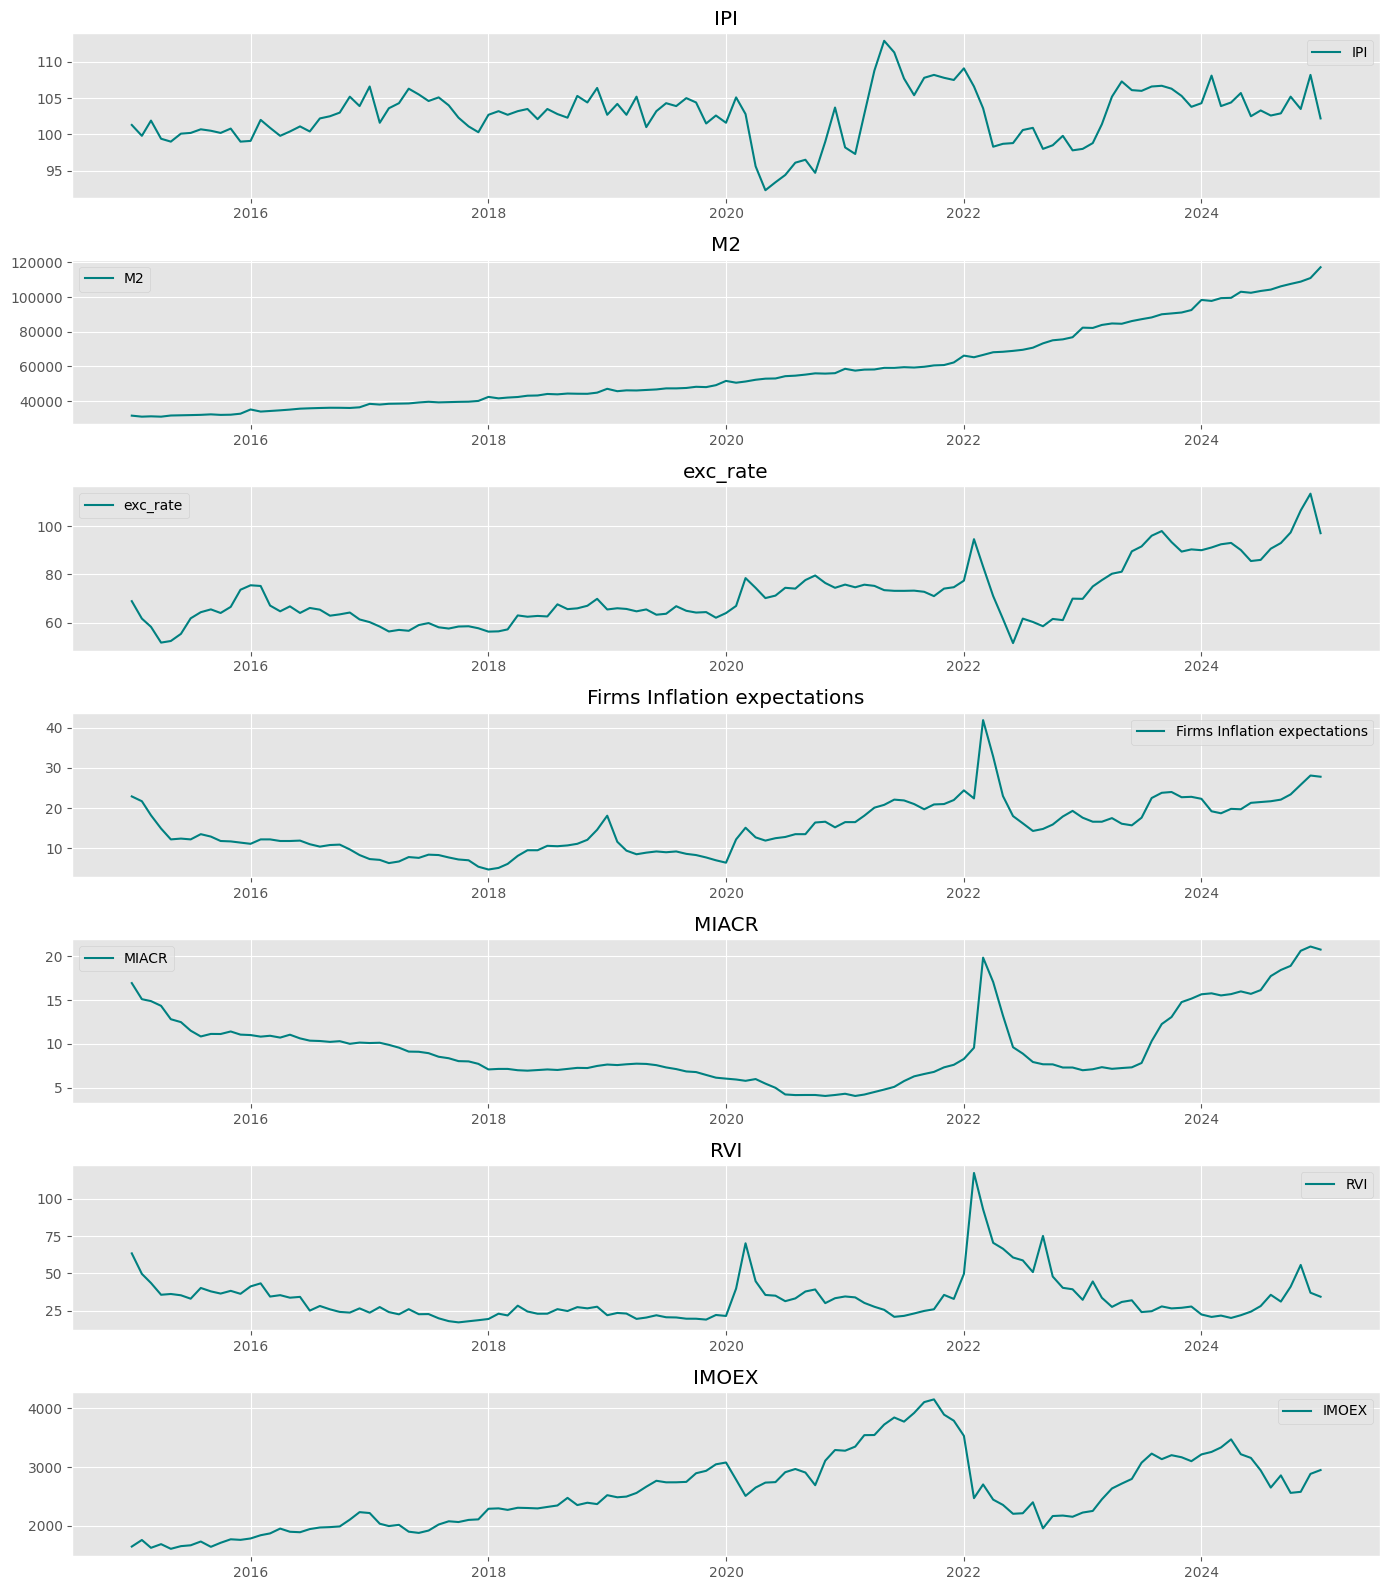

In [77]:
variables = ['IPI', 'М2', 'exc_rate', 'Firms Inflation expectations', 'MIACR', 'RVI', 'IMOEX']
plt.figure(figsize=(14, 16))

for i, column in enumerate(variables, 1):
    plt.subplot(len(variables), 1, i)
    plt.plot(df.index, df[column], label=column, color='teal')
    plt.title(column)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

In [78]:
df['M2_detrended'] = detrend(df['М2'])   #детрендировала денежную массу  
df = df.drop(columns=['М2'])
df['shock_2022'] = ((df.index >= '2022-02-01') & (df.index <= '2022-07-31')).astype(int) #шок на 2022
df['y_L1'] = df['CPI'].shift(1) #три лага CPI
df['y_L2'] = df['CPI'].shift(2)
df['y_L12'] = df['CPI'].shift(12)
df = df.dropna()

## Бенчмарки без кросс-валидации

In [79]:
train_size = int(len(df) * 0.7) 
X_train, X_test = df[:train_size].drop(columns=['CPI']), df[train_size:].drop(columns=['CPI'])
y_train, y_test = df.CPI[:train_size], df.CPI[train_size:]

# errors_naive = []
# errors_ar = []
# errors_arima = [] 

y_pred_naive = X_test.iloc[:, -1].values 
# errors_naive = np.abs(y_test - y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
mape_naive = np.mean(np.abs((y_test - y_pred_naive) / y_test)) * 100

print(f'RMSE для модели Naive: {rmse_naive:.4f}')
print(f'MAPE для модели Naive: {mape_naive:.2f}%')
#AR(1)
model_ar = AutoReg(y_train, lags=1)  
model_ar_fitted = model_ar.fit()

y_pred_ar = model_ar_fitted.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)
# errors_ar = np.abs(y_test - y_pred_ar)

rmse_ar = np.sqrt(mean_squared_error(y_test, y_pred_ar))
mape_ar = np.mean(np.abs((y_test - y_pred_ar) / y_test)) * 100

print(f'\nRMSE для модели AR: {rmse_ar:.4f}')
print(f'MAPE для модели AR: {mape_ar:.2f}%')

#Auto-ARIMA
model_arima = auto_arima(y_train, seasonal=False, trace=True, error_action='ignore', suppress_warnings=True)

y_pred_arima = model_arima.predict(n_periods=len(y_test))
# errors_arima = np.abs(y_test - y_pred_arima)

rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
mape_arima = np.mean(np.abs((y_test - y_pred_arima) / y_test)) * 100

print(f'\nRMSE для модели ARIMA: {rmse_arima:.4f}')
print(f'MAPE для модели ARIMA: {mape_arima:.2f}%')

RMSE для модели Naive: 1.3872
MAPE для модели Naive: 0.69%

RMSE для модели AR: 0.4765
MAPE для модели AR: 0.37%
Performing stepwise search to minimize aic


C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=196.156, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=224.296, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=191.820, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=190.956, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=222.300, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=192.365, Time=0.12 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=192.395, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=194.186, Time=0.21 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=189.972, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=191.284, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=191.294, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=190.550, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=193.118, Time=0.17 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 1.347 seconds

RMSE для модели ARIMA: 1.8916
MAPE для модели ARIMA: 1.83%


## Бенчмарки с кросс-валидацией

In [80]:
tscv = TimeSeriesSplit(n_splits=5, test_size=6)

errors_naive = []
errors_ar = []
errors_arima = []

for train_index, test_index in tscv.split(df):
    train, test = df.iloc[train_index], df.iloc[test_index]
    y_train, y_test = train['CPI'], test['CPI']

    y_pred_naive = y_train.iloc[-1]
    y_pred_naive = np.repeat(y_pred_naive, len(y_test))
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
    mape_naive = mean_absolute_percentage_error(y_test, y_pred_naive)
    errors_naive.append((rmse_naive, mape_naive))

    model_ar = AutoReg(y_train, lags=1)
    model_ar_fitted = model_ar.fit()
    y_pred_ar = model_ar_fitted.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)
    rmse_ar = np.sqrt(mean_squared_error(y_test, y_pred_ar))
    mape_ar = mean_absolute_percentage_error(y_test, y_pred_ar)
    errors_ar.append((rmse_ar, mape_ar))

    model_arima = auto_arima(y_train, seasonal=False, trace=False, error_action='ignore', suppress_warnings=True)
    y_pred_arima = model_arima.predict(n_periods=len(y_test))
    rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
    mape_arima = mean_absolute_percentage_error(y_test, y_pred_arima)
    errors_arima.append((rmse_arima, mape_arima))

mean_rmse_naive = np.mean([e[0] for e in errors_naive])
mean_mape_naive = np.mean([e[1] for e in errors_naive])
mean_rmse_ar = np.mean([e[0] for e in errors_ar])
mean_mape_ar = np.mean([e[1] for e in errors_ar])
mean_rmse_arima = np.mean([e[0] for e in errors_arima])
mean_mape_arima = np.mean([e[1] for e in errors_arima])

print(f'Средний RMSE для наивной модели: {mean_rmse_naive:.4f}')
print(f'Средний MAPE для наивной модели: {mean_mape_naive:.2%}')
print(f'Средний RMSE для модели AR(1): {mean_rmse_ar:.4f}')
print(f'Средний MAPE для модели AR(1): {mean_mape_ar:.2%}')
print(f'Средний RMSE для модели автоARIMA: {mean_rmse_arima:.4f}')
print(f'Средний MAPE для модели автоARIMA: {mean_mape_arima:.2%}')


C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with

Средний RMSE для наивной модели: 0.4705
Средний MAPE для наивной модели: 0.42%
Средний RMSE для модели AR(1): 0.3739
Средний MAPE для модели AR(1): 0.32%
Средний RMSE для модели автоARIMA: 0.3718
Средний MAPE для модели автоARIMA: 0.32%


In [81]:
def time_series_cv_with_metrics(df, features, target, model, n_splits=5):
    df = df.dropna()

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=6)  

    rmse_list = []
    mape_list = []
    fold = 1

    for train_index, test_index in tscv.split(df):
        train, test = df.iloc[train_index], df.iloc[test_index]

        X_train, y_train = train[features], train[target]
        X_test, y_test = test[features], test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  
        rmse_list.append(rmse)
        mape_list.append(mape)

        print(f'Фолд {fold} — RMSE: {rmse:.2f}, MAPE: {mape:.2f}%')  
        fold += 1

    print(f'\nСредний RMSE: {np.mean(rmse_list):.2f}')
    print(f'Средний MAPE: {np.mean(mape_list):.2f}%\n')  

    return np.mean(rmse_list), np.mean(mape_list)

features = [col for col in df.columns if col != 'CPI']
target = 'CPI'

models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'SVM': SVR(kernel='rbf'),
    'MLP': MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42),
    'GBR': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

for model_name, model in models.items():
    print(f' Модель: {model_name}')
    time_series_cv_with_metrics(df, features, target, model)



 Модель: RandomForest
Фолд 1 — RMSE: 0.21, MAPE: 0.13%
Фолд 2 — RMSE: 0.40, MAPE: 0.40%
Фолд 3 — RMSE: 0.32, MAPE: 0.29%
Фолд 4 — RMSE: 0.24, MAPE: 0.21%
Фолд 5 — RMSE: 1.64, MAPE: 1.53%

Средний RMSE: 0.56
Средний MAPE: 0.51%

 Модель: XGBoost
Фолд 1 — RMSE: 0.30, MAPE: 0.26%
Фолд 2 — RMSE: 0.32, MAPE: 0.27%
Фолд 3 — RMSE: 0.30, MAPE: 0.26%
Фолд 4 — RMSE: 0.26, MAPE: 0.20%
Фолд 5 — RMSE: 0.42, MAPE: 0.35%

Средний RMSE: 0.32
Средний MAPE: 0.27%

 Модель: SVM
Фолд 1 — RMSE: 0.46, MAPE: 0.38%
Фолд 2 — RMSE: 0.11, MAPE: 0.08%
Фолд 3 — RMSE: 0.27, MAPE: 0.23%
Фолд 4 — RMSE: 0.37, MAPE: 0.33%
Фолд 5 — RMSE: 0.51, MAPE: 0.45%

Средний RMSE: 0.35
Средний MAPE: 0.29%

 Модель: MLP
Фолд 1 — RMSE: 78.61, MAPE: 67.37%
Фолд 2 — RMSE: 51.53, MAPE: 49.42%
Фолд 3 — RMSE: 135.18, MAPE: 114.80%
Фолд 4 — RMSE: 337.60, MAPE: 330.35%
Фолд 5 — RMSE: 500.61, MAPE: 474.37%

Средний RMSE: 220.71
Средний MAPE: 207.26%

 Модель: GBR
Фолд 1 — RMSE: 0.20, MAPE: 0.11%
Фолд 2 — RMSE: 0.43, MAPE: 0.37%
Фолд 3 — RMS

## Тест Диболда-Мариано

In [82]:
def benchmark_baseline_models(df):
    tscv = TimeSeriesSplit(n_splits=5, test_size=6)

    predictions_naive = []
    predictions_ar = []
    predictions_arima = []
    actual_values = []

    for train_index, test_index in tscv.split(df):
        train, test = df.iloc[train_index], df.iloc[test_index]
        y_train, y_test = train['CPI'], test['CPI']
        actual_values.extend(y_test)

        y_pred_naive = np.repeat(y_train.iloc[-1], len(y_test))
        predictions_naive.extend(y_pred_naive)

        model_ar = AutoReg(y_train, lags=1)
        model_ar_fitted = model_ar.fit()
        y_pred_ar = model_ar_fitted.predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)
        predictions_ar.extend(y_pred_ar)

        model_arima = auto_arima(y_train, seasonal=False, trace=False, error_action='ignore', suppress_warnings=True)
        y_pred_arima = model_arima.predict(n_periods=len(y_test))
        predictions_arima.extend(y_pred_arima)

    return predictions_naive, predictions_ar, predictions_arima, actual_values


def time_series_cv_with_metrics(df, features, target, model, n_splits=5):
    df = df.dropna()

    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=6)  

    predictions = []  
    actual_values = []

    for train_index, test_index in tscv.split(df):
        train, test = df.iloc[train_index], df.iloc[test_index]

        X_train, y_train = train[features], train[target]
        X_test, y_test = test[features], test[target]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        predictions.extend(y_pred) 
        actual_values.extend(y_test)  
    return predictions, actual_values

def compare_models_with_dm_test(model1_name, model2_name, all_predictions, actual_lst, crit="MAPE"):
    pred1_lst = all_predictions[model1_name]
    pred2_lst = all_predictions[model2_name]
    
    if len(actual_lst) != len(pred1_lst) or len(actual_lst) != len(pred2_lst):
        raise ValueError("Lengths of actual_lst, pred1_lst, and pred2_lst do not match.")

    result = dm_test(actual_lst, pred1_lst, pred2_lst, crit=crit)   
    print(f'{model1_name} vs {model2_name} — DM test statistic: {result.DM:.4f}, p-value: {result.p_value:.4f}')

predictions_naive, predictions_ar, predictions_arima, actual_values = benchmark_baseline_models(df)
features = [col for col in df.columns if col != 'CPI']
target = 'CPI'

models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(objective='reg:squarederror', random_state=42),
    'SVM': SVR(kernel='rbf'),
    'MLP': MLPRegressor(hidden_layer_sizes=(50, 50), max_iter=500, random_state=42),
    'GBR': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

all_predictions = {}
all_predictions['Naive'] = predictions_naive
all_predictions['AR(1)'] = predictions_ar
all_predictions['ARIMA'] = predictions_arima

for model_name, model in models.items():
    predictions, _ = time_series_cv_with_metrics(df, features, target, model)
    all_predictions[model_name] = predictions


C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\murad\.anaconda\anaconda2024\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with

ARIMA vs RandomForest — DM test statistic: -2.0024, p-value: 0.0547
ARIMA vs GBR — DM test statistic: -2.1749, p-value: 0.0379
ARIMA vs MLP — DM test statistic: -6.0532, p-value: 0.0000
ARIMA vs SVM — DM test statistic: 0.8318, p-value: 0.4123
ARIMA vs XGBoost — DM test statistic: 1.4180, p-value: 0.1668
Naive vs RandomForest — DM test statistic: -0.7130, p-value: 0.4816
Naive vs GBR — DM test statistic: -1.5905, p-value: 0.1226
Naive vs MLP — DM test statistic: -6.0434, p-value: 0.0000
Naive vs SVM — DM test statistic: 1.9108, p-value: 0.0660
Naive vs XGBoost — DM test statistic: 2.5238, p-value: 0.0173
AR(1) vs RandomForest — DM test statistic: -1.9926, p-value: 0.0558
AR(1) vs GBR — DM test statistic: -2.1743, p-value: 0.0380
AR(1) vs MLP — DM test statistic: -6.0532, p-value: 0.0000
AR(1) vs SVM — DM test statistic: 0.8521, p-value: 0.4012
AR(1) vs XGBoost — DM test statistic: 1.4125, p-value: 0.1685


In [83]:
base_models = ['ARIMA', 'Naive', 'AR(1)']
big_models = ['RandomForest', 'GBR', 'MLP', 'SVM', 'XGBoost']

for base_model in base_models:
    for big_model in big_models:
        compare_models_with_dm_test(base_model, big_model, all_predictions, actual_values)

ARIMA vs RandomForest — DM test statistic: -2.0024, p-value: 0.0547
ARIMA vs GBR — DM test statistic: -2.1749, p-value: 0.0379
ARIMA vs MLP — DM test statistic: -6.0532, p-value: 0.0000
ARIMA vs SVM — DM test statistic: 0.8318, p-value: 0.4123
ARIMA vs XGBoost — DM test statistic: 1.4180, p-value: 0.1668
Naive vs RandomForest — DM test statistic: -0.7130, p-value: 0.4816
Naive vs GBR — DM test statistic: -1.5905, p-value: 0.1226
Naive vs MLP — DM test statistic: -6.0434, p-value: 0.0000
Naive vs SVM — DM test statistic: 1.9108, p-value: 0.0660
Naive vs XGBoost — DM test statistic: 2.5238, p-value: 0.0173
AR(1) vs RandomForest — DM test statistic: -1.9926, p-value: 0.0558
AR(1) vs GBR — DM test statistic: -2.1743, p-value: 0.0380
AR(1) vs MLP — DM test statistic: -6.0532, p-value: 0.0000
AR(1) vs SVM — DM test statistic: 0.8521, p-value: 0.4012
AR(1) vs XGBoost — DM test statistic: 1.4125, p-value: 0.1685
